In [ ]:
# Install SAELens and TransformerLens
!pip install -q sae-lens transformer-lens

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 5.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 145.1/145.1 kB 14.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 249.2/249.2 kB 24.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 195.2/195.2 kB 20.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 739.7/739.7 kB 58.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.1/56.1 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 109.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.0/41.0 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 273.7/273.7 kB 22.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 236.6/236.6 kB 20.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This beha

In [ ]:
from huggingface_hub import notebook_login
# Login to HuggingFace
notebook_login()

In [ ]:
# Fix numpy compatibility issue
!pip uninstall -y numpy
!pip install numpy==1.26.4
!pip install -q sae-lens transformer-lens

Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Successfully uninstalled numpy-1.26.4
  Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.0 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
opencv

KeyboardInterrupt: 

In [ ]:
import numpy as np
from sae_lens import SAE
import transformer_lens
from collections import defaultdict, Counter
from scipy.stats import ttest_ind, fisher_exact
import pandas as pd
import torch
from transformers import AutoTokenizer
from tqdm import tqdm
from functools import partial
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.9.0+cu126
CUDA available: True
GPU: NVIDIA A100-SXM4-80GB


In [ ]:
print("Loading Gemma 9B IT model with TransformerLens...")
print("This will take a few minutes...")

# Load the model using TransformerLens for activation extraction
tl_model = transformer_lens.HookedTransformer.from_pretrained(
    "google/gemma-2-9b-it",
    device="cuda",
    dtype=torch.bfloat16,
)

print("Model loaded successfully!")
print(f"Model has {tl_model.cfg.n_layers} layers")
print(f"Model dimension: {tl_model.cfg.d_model}")

Loading Gemma 9B IT model with TransformerLens...
This will take a few minutes...


config.json:   0%|          | 0.00/857 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors.index.json:   0%|          | 0.00/39.1k [00:00<?, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

...

tokenizer_config.json:   0%|          | 0.00/47.0k [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/4.24M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.5M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/636 [00:00<?, ?B/s]

Loaded pretrained model google/gemma-2-9b-it into HookedTransformer
Model loaded successfully!
Model has 42 layers
Model dimension: 3584


In [ ]:
# ============================================================================
# CELL 1: LOAD LAYER 20 SAE
# ============================================================================

print("Loading SAE from Gemma Scope...")
print("Repository: google/gemma-scope-9b-it-res")
print("Layer: 20 (MID-LAYER), Width: 131k")

sae, cfg_dict, sparsity = SAE.from_pretrained(
    release="gemma-scope-9b-it-res-canonical",
    sae_id="layer_20/width_131k/canonical",
    device="cuda"
)

print(f"\nSAE loaded successfully!")
print(f"SAE width (number of features): {sae.cfg.d_sae}")
print(f"SAE input dimension: {sae.cfg.d_in}")
print(f"Average L0 (sparsity): {sparsity}")
print(f"Hook point: blocks.20.hook_resid_post")

Loading SAE from Gemma Scope...
Repository: google/gemma-scope-9b-it-res
Layer: 20 (MID-LAYER), Width: 16k


layer_20/width_131k/average_l0_81/params(…):   0%|          | 0.00/3.76G [00:00<?, ?B/s]


SAE loaded successfully!
SAE width (number of features): 131072
SAE input dimension: 3584
Average L0 (sparsity): None
Hook point: blocks.20.hook_resid_post


In [ ]:
# ============================================================================
# CELL 2: LOAD ALL THREE DATASETS
# ============================================================================

print("="*80)
print("CROSS-LINGUISTIC ANALYSIS - LAYER 20")
print("Loading English, Hebrew, and Russian datasets...")
print("="*80)

print("\n1. Loading English dataset...")
english_df = pd.read_csv("/content/unified_english_dataset.csv")
english_df = english_df.dropna(subset=['sentence', 'term', 'classification'])
english_df['language'] = 'English'
print(f"   English: {len(english_df)} rows")
print(f"   Classifications: {english_df['classification'].value_counts().to_dict()}")

print("\n2. Loading Hebrew dataset...")
hebrew_df = pd.read_csv("/content/hebrew_slang_classification_results.csv")

hebrew_rows = []
for _, row in hebrew_df.iterrows():
    sentence = row['sentence']
    slang_words = str(row['slang_words']).strip()
    classification = 'Slang' if row['classification'] == 'Yes' else 'Literal'
    terms = [t.strip() for t in slang_words.replace(',', ' ').split() if t.strip()]
    for term in terms:
        hebrew_rows.append({
            'sentence': sentence,
            'term': term,
            'classification': classification,
            'language': 'Hebrew'
        })

hebrew_df = pd.DataFrame(hebrew_rows)
print(f"   Hebrew: {len(hebrew_df)} rows")
print(f"   Classifications: {hebrew_df['classification'].value_counts().to_dict()}")

print("\n3. Loading Russian datasets...")
russian_slang_df = pd.read_csv("/content/russian_slang_positive_results.csv")
russian_literal_df = pd.read_csv("/content/russian_literal_negatives_dataset.csv")

russian_slang_rows = []
for _, row in russian_slang_df.iterrows():
    russian_slang_rows.append({
        'sentence': row['text'],
        'term': row['slang_term'],
        'classification': 'Slang',
        'language': 'Russian'
    })

russian_literal_rows = []
for _, row in russian_literal_df.iterrows():
    russian_literal_rows.append({
        'sentence': row['text'],
        'term': row['slang_term'],
        'classification': 'Literal',
        'language': 'Russian'
    })

russian_df = pd.DataFrame(russian_slang_rows + russian_literal_rows)
print(f"   Russian: {len(russian_df)} rows")
print(f"   Classifications: {russian_df['classification'].value_counts().to_dict()}")

unified_df = pd.concat([english_df, hebrew_df, russian_df], ignore_index=True)

print("\n" + "="*80)
print("DATASET SUMMARY")
print("="*80)
print(f"\nEnglish:  {len(english_df):,} rows")
print(f"Hebrew:   {len(hebrew_df):,} rows")
print(f"Russian:  {len(russian_df):,} rows")
print(f"TOTAL:    {len(unified_df):,} rows")

datasets = {
    'English': english_df,
    'Hebrew': hebrew_df,
    'Russian': russian_df
}

print("\n✓ All datasets loaded")

CROSS-LINGUISTIC ANALYSIS - LAYER 20
Loading English, Hebrew, and Russian datasets...

1. Loading English dataset...
   English: 2835 rows
   Classifications: {'Literal': 1857, 'Slang': 968, 'Unknown': 10}

2. Loading Hebrew dataset...
   Hebrew: 4527 rows
   Classifications: {'Literal': 2751, 'Slang': 1776}

3. Loading Russian datasets...
   Russian: 1259 rows
   Classifications: {'Literal': 721, 'Slang': 538}

DATASET SUMMARY

English:  2,835 rows
Hebrew:   4,527 rows
Russian:  1,259 rows
TOTAL:    8,621 rows

✓ All datasets loaded


In [ ]:
# ============================================================================
# CELL 3: TERM DISTRIBUTION ANALYSIS PER LANGUAGE
# ============================================================================

print("="*80)
print("TERM DISTRIBUTION ANALYSIS PER LANGUAGE")
print("="*80)

MIN_EXAMPLES = 10
terms_for_analysis_per_lang = {}

for lang_name, lang_df in datasets.items():
    print(f"\n{'='*80}")
    print(f"{lang_name.upper()}")
    print(f"{'='*80}")

    term_class_counts = lang_df.groupby(['term', 'classification']).size().unstack(fill_value=0)

    if 'Slang' not in term_class_counts.columns:
        term_class_counts['Slang'] = 0
    if 'Literal' not in term_class_counts.columns:
        term_class_counts['Literal'] = 0

    terms_with_both = term_class_counts[
        (term_class_counts['Slang'] > 0) & (term_class_counts['Literal'] > 0)
    ].sort_values('Slang', ascending=False)

    print(f"\nTotal unique terms: {len(term_class_counts)}")
    print(f"Terms with BOTH slang and literal examples: {len(terms_with_both)}")
    print(f"Terms with ONLY slang examples: {(term_class_counts['Literal'] == 0).sum()}")
    print(f"Terms with ONLY literal examples: {(term_class_counts['Slang'] == 0).sum()}")

    terms_for_analysis = terms_with_both[
        (terms_with_both['Slang'] >= MIN_EXAMPLES) &
        (terms_with_both['Literal'] >= MIN_EXAMPLES)
    ]
    terms_for_analysis_per_lang[lang_name] = terms_for_analysis

    print(f"\nTerms with at least {MIN_EXAMPLES} examples in BOTH categories: {len(terms_for_analysis)}")
    if len(terms_for_analysis) > 0:
        print(terms_for_analysis.head(10))

    if len(terms_with_both) > 0:
        print(f"\nTop 10 terms with both slang and literal examples:")
        print(terms_with_both.head(10))

TERM DISTRIBUTION ANALYSIS PER LANGUAGE

ENGLISH

Total unique terms: 130
Terms with BOTH slang and literal examples: 86
Terms with ONLY slang examples: 32
Terms with ONLY literal examples: 12

Terms with at least 10 examples in BOTH categories: 17
classification  Literal  Slang  Unknown
term                                   
off                 123     55        1
man                 172     55        0
hit                  12     45        0
check                24     36        0
bad                  77     28        0
hot                  15     23        0
fire                 18     23        0
cool                 16     23        0
hard                 59     22        0
head                 52     19        0

Top 10 terms with both slang and literal examples:
classification  Literal  Slang  Unknown
term                                   
off                 123     55        1
man                 172     55        0
hit                  12     45        0
check              

In [ ]:
# ============================================================================
# CELL 4: HELPER FUNCTION - FIND TERM TOKEN POSITIONS
# ============================================================================

def find_term_token_positions(sentence, term, tl_model):
    term_clean = term.lower().strip()
    sentence_lower = sentence.lower()

    char_start = sentence_lower.find(term_clean)
    if char_start == -1:
        return []
    char_end = char_start + len(term_clean)

    token_strs = tl_model.to_str_tokens(sentence, prepend_bos=True)

    term_positions = []
    current_pos = 0

    for token_idx in range(len(token_strs)):
        if token_idx == 0:
            continue

        token_str = token_strs[token_idx]
        token_len = len(token_str)
        token_start = current_pos
        token_end = current_pos + token_len

        if token_start < char_end and token_end > char_start:
            term_positions.append(token_idx)

        current_pos = token_end

    return term_positions

print("Testing token position finder...")
for lang_name, lang_df in datasets.items():
    if len(lang_df) > 0:
        test_sentence = lang_df.iloc[0]['sentence']
        test_term = lang_df.iloc[0]['term']
        test_positions = find_term_token_positions(test_sentence, test_term, tl_model)
        print(f"\n{lang_name}: '{test_term}' in '{test_sentence[:50]}...'")
        print(f"  Found at positions: {test_positions}")

print("\n✓ Token position finder defined and tested")

Testing token position finder...

English: 'jam' in 'If you get into a jam, you can call me....'
  Found at positions: [6]

Hebrew: 'אש' in 'אתה לא נשיא במקרה ? ? ? ? כן זה שהתפקיד שלו זה לבז...'
  Found at positions: [75]

Russian: 'огонь' in 'Дубленка, эко-кожа
Размеры 42-44-46-48
Новый колле...'
  Found at positions: [46]

✓ Token position finder defined and tested


In [ ]:
# ============================================================================
# CELL 5: HELPER FUNCTION - EXTRACT LAYER 20 FEATURES FOR ALL TOKENS
# ============================================================================

import gc
from tqdm import tqdm
from collections import Counter

def extract_features_with_labels(df, tl_model, sae, batch_size=8):
    all_features = []
    all_labels = []
    all_info = []

    print(f"\nProcessing {len(df)} sentences...")
    print("Extracting Layer 20 SAE features for ALL tokens (SKIPPING BOS)...\n")

    for idx in tqdm(range(0, len(df), batch_size), desc="Processing batches"):
        batch_df = df.iloc[idx:idx+batch_size]

        for _, row in batch_df.iterrows():
            sentence = str(row['sentence'])
            term = str(row['term']).strip()
            classification = row['classification']
            language = row.get('language', 'Unknown')

            term_positions = find_term_token_positions(sentence, term, tl_model)

            if not term_positions:
                continue

            tokens = tl_model.to_tokens(sentence, prepend_bos=True)
            token_strs = tl_model.to_str_tokens(sentence, prepend_bos=True)

            with torch.no_grad():
                _, cache = tl_model.run_with_cache(
                    tokens,
                    names_filter=lambda name: name == "blocks.20.hook_resid_post"
                )

                layer_20_acts = cache["blocks.20.hook_resid_post"]

                for token_idx in range(1, layer_20_acts.shape[1]):
                    token_act = layer_20_acts[0, token_idx, :]
                    sae_features = sae.encode(token_act.unsqueeze(0))

                    is_term = token_idx in term_positions
                    is_slang = classification == 'Slang'

                    if is_term and is_slang:
                        label = 'slang_term'
                    elif is_term and not is_slang:
                        label = 'literal_term'
                    elif not is_term and is_slang:
                        label = 'slang_context'
                    else:
                        label = 'literal_context'

                    all_features.append(sae_features[0].cpu())
                    all_labels.append(label)
                    all_info.append({
                        'sentence': sentence,
                        'term': term,
                        'token_idx': token_idx,
                        'token_str': token_strs[token_idx],
                        'label': label,
                        'classification': classification,
                        'language': language
                    })

                del cache, tokens, layer_20_acts
                torch.cuda.empty_cache()

        if idx % (batch_size * 10) == 0:
            gc.collect()
            torch.cuda.empty_cache()

    return all_features, all_labels, all_info

print("✓ Feature extraction function defined for Layer 20 (ALL tokens)")

✓ Feature extraction function defined for Layer 20 (ALL tokens)


In [ ]:
# ============================================================================
# CELL 6: HELPER FUNCTION - EXTRACT LAYER 20 FEATURES (TERM TOKENS ONLY)
# ============================================================================

def extract_term_features_layer20(df, tl_model, sae, batch_size=4):
    all_features = []
    all_labels = []
    all_info = []

    print(f"\nProcessing {len(df)} sentences...")
    print("Extracting Layer 20 SAE features for TERM TOKENS ONLY...\n")

    for idx in tqdm(range(0, len(df), batch_size), desc="Processing batches"):
        batch_df = df.iloc[idx:idx+batch_size]

        for _, row in batch_df.iterrows():
            sentence = str(row['sentence'])
            term = str(row['term']).strip()
            classification = row['classification']
            language = row['language']

            term_positions = find_term_token_positions(sentence, term, tl_model)

            if not term_positions:
                continue

            tokens = tl_model.to_tokens(sentence, prepend_bos=True)
            token_strs = tl_model.to_str_tokens(sentence, prepend_bos=True)

            with torch.no_grad():
                _, cache = tl_model.run_with_cache(
                    tokens,
                    names_filter=lambda name: name == "blocks.20.hook_resid_post"
                )

                layer_20_acts = cache["blocks.20.hook_resid_post"]

                for token_idx in term_positions:
                    if token_idx == 0:
                        continue

                    token_act = layer_20_acts[0, token_idx, :]
                    sae_features = sae.encode(token_act.unsqueeze(0))

                    label = 'slang_term' if classification == 'Slang' else 'literal_term'

                    all_features.append(sae_features[0].cpu())
                    all_labels.append(label)
                    all_info.append({
                        'sentence': sentence,
                        'term': term,
                        'token_idx': token_idx,
                        'token_str': token_strs[token_idx],
                        'label': label,
                        'classification': classification,
                        'language': language
                    })

                del cache, tokens, layer_20_acts
                torch.cuda.empty_cache()

        if idx % (batch_size * 10) == 0:
            gc.collect()
            torch.cuda.empty_cache()

    print(f"\nExtracted {len(all_features)} term tokens")
    gc.collect()
    torch.cuda.empty_cache()

    return all_features, all_labels, all_info

print("✓ Feature extraction function defined for Layer 20 (TERM tokens only)")

✓ Feature extraction function defined for Layer 20 (TERM tokens only)


In [ ]:
# ============================================================================
# CELL 7: EXTRACT LAYER 20 FEATURES FOR ALL LANGUAGES
# ============================================================================

import pickle
import os

print("="*80)
print("EXTRACTING LAYER 20 SAE FEATURES FOR ALL LANGUAGES")
print("="*80)

language_results = {}

for lang_name, lang_df in datasets.items():
    checkpoint_path = f'/content/{lang_name}_layer20_term_features.pkl'

    if os.path.exists(checkpoint_path):
        print(f"\n✓ Loading cached results for {lang_name}...")
        with open(checkpoint_path, 'rb') as f:
            language_results[lang_name] = pickle.load(f)
        print(f"✓ {lang_name} loaded from checkpoint")
        continue

    print(f"\n{'='*80}")
    print(f"PROCESSING {lang_name.upper()}")
    print(f"{'='*80}")

    gc.collect()
    torch.cuda.empty_cache()

    features, labels, info = extract_term_features_layer20(
        df=lang_df,
        tl_model=tl_model,
        sae=sae,
        batch_size=4
    )

    features = torch.stack(features)
    labels = np.array(labels)

    slang_term_mask = labels == 'slang_term'
    literal_term_mask = labels == 'literal_term'

    slang_term_features = features[slang_term_mask]
    literal_term_features = features[literal_term_mask]

    slang_term_info = [i for i, l in zip(info, labels) if l == 'slang_term']
    literal_term_info = [i for i, l in zip(info, labels) if l == 'literal_term']

    slang_term_counts = Counter([i['term'] for i in slang_term_info])
    literal_term_counts = Counter([i['term'] for i in literal_term_info])

    language_results[lang_name] = {
        'all_features': features,
        'all_labels': labels,
        'all_info': info,
        'slang_term_features': slang_term_features,
        'literal_term_features': literal_term_features,
        'slang_term_info': slang_term_info,
        'literal_term_info': literal_term_info,
        'slang_term_counts': slang_term_counts,
        'literal_term_counts': literal_term_counts
    }

    with open(checkpoint_path, 'wb') as f:
        pickle.dump(language_results[lang_name], f)
    print(f"\n✓ Checkpoint saved for {lang_name}")

    print(f"\n{lang_name} Results:")
    print(f"  Slang term tokens:     {slang_term_mask.sum():,}")
    print(f"  Literal term tokens:   {literal_term_mask.sum():,}")
    print(f"  Total term tokens:     {len(features):,}")
    print(f"  Unique slang terms:    {len(slang_term_counts)}")
    print(f"  Unique literal terms:  {len(literal_term_counts)}")

    del features, labels, info, slang_term_mask, literal_term_mask
    gc.collect()
    torch.cuda.empty_cache()

print("\n" + "="*80)
print("✓ Feature extraction complete for all languages")
print("="*80)

EXTRACTING LAYER 20 SAE FEATURES FOR ALL LANGUAGES

PROCESSING ENGLISH

Processing 2835 sentences...
Extracting Layer 20 SAE features for TERM TOKENS ONLY...



Processing batches: 100%|██████████| 709/709 [06:02<00:00,  1.96it/s]



Extracted 2844 term tokens

✓ Checkpoint saved for English

English Results:
  Slang term tokens:     977
  Literal term tokens:   1,867
  Total term tokens:     2,844
  Unique slang terms:    118
  Unique literal terms:  101

PROCESSING HEBREW

Processing 4527 sentences...
Extracting Layer 20 SAE features for TERM TOKENS ONLY...



Processing batches: 100%|██████████| 1132/1132 [10:50<00:00,  1.74it/s]



Extracted 8256 term tokens

✓ Checkpoint saved for Hebrew

Hebrew Results:
  Slang term tokens:     3,300
  Literal term tokens:   4,956
  Total term tokens:     8,256
  Unique slang terms:    18
  Unique literal terms:  18

PROCESSING RUSSIAN

Processing 1259 sentences...
Extracting Layer 20 SAE features for TERM TOKENS ONLY...



Processing batches: 100%|██████████| 315/315 [02:17<00:00,  2.30it/s]



Extracted 1853 term tokens

✓ Checkpoint saved for Russian

Russian Results:
  Slang term tokens:     979
  Literal term tokens:   874
  Total term tokens:     1,853
  Unique slang terms:    15
  Unique literal terms:  14

✓ Feature extraction complete for all languages


In [ ]:
# ============================================================================
# CELL 8: ANALYSIS - SLANG VS LITERAL COMPARISON PER LANGUAGE (LAYER 20)
# ============================================================================

from scipy.stats import ttest_ind

print("="*80)
print("LAYER 20: SLANG VS LITERAL ANALYSIS PER LANGUAGE")
print("="*80)

per_language_stats = {}

for lang_name in ['English', 'Hebrew', 'Russian']:
    print(f"\n{'='*80}")
    print(f"{lang_name.upper()} - LAYER 20")
    print(f"{'='*80}")

    slang_feats = language_results[lang_name]['slang_term_features']
    literal_feats = language_results[lang_name]['literal_term_features']

    if len(literal_feats) == 0:
        print(f"⚠️ No literal examples for {lang_name}, skipping comparison")
        continue

    slang_l0 = (slang_feats > 0).sum(dim=1).float()
    literal_l0 = (literal_feats > 0).sum(dim=1).float()

    print(f"\n1. FEATURE SPARSITY (L0):")
    print(f"   Slang:   {slang_l0.mean():.2f} ± {slang_l0.std():.2f} active features")
    print(f"   Literal: {literal_l0.mean():.2f} ± {literal_l0.std():.2f} active features")
    print(f"   Diff:    {slang_l0.mean() - literal_l0.mean():+.2f}")

    t_stat, p_value = ttest_ind(slang_l0.numpy(), literal_l0.numpy())
    print(f"   T-test: t={t_stat:.4f}, p={p_value:.4e}")

    if p_value < 0.001:
        print("   ✓✓✓ HIGHLY SIGNIFICANT difference (p < 0.001)")
    elif p_value < 0.05:
        print("   ✓ Significant difference (p < 0.05)")
    else:
        print("   ✗ Not statistically significant")

    slang_l1 = slang_feats.sum(dim=1)
    literal_l1 = literal_feats.sum(dim=1)

    print(f"\n2. ACTIVATION STRENGTH (L1):")
    print(f"   Slang:   {slang_l1.mean():.2f} ± {slang_l1.std():.2f}")
    print(f"   Literal: {literal_l1.mean():.2f} ± {literal_l1.std():.2f}")
    print(f"   Diff:    {slang_l1.mean() - literal_l1.mean():+.2f}")

    t_stat_l1, p_value_l1 = ttest_ind(slang_l1.numpy(), literal_l1.numpy())
    print(f"   T-test: t={t_stat_l1:.4f}, p={p_value_l1:.4e}")

    slang_freq = (slang_feats > 0).float().mean(dim=0)
    literal_freq = (literal_feats > 0).float().mean(dim=0)
    freq_diff = slang_freq - literal_freq

    top_features = torch.topk(freq_diff, k=20)

    print(f"\n3. TOP 10 DISCRIMINATIVE FEATURES:")
    print(f"   {'Feature':<10} {'Slang%':<10} {'Literal%':<10} {'Diff':<10}")
    print(f"   {'-'*40}")
    for i in range(10):
        feat_idx = top_features.indices[i].item()
        print(f"   {feat_idx:<10} {slang_freq[feat_idx]:.1%}      {literal_freq[feat_idx]:.1%}      {freq_diff[feat_idx]:+.1%}")

    per_language_stats[lang_name] = {
        'slang_l0_mean': slang_l0.mean().item(),
        'literal_l0_mean': literal_l0.mean().item(),
        'slang_l1_mean': slang_l1.mean().item(),
        'literal_l1_mean': literal_l1.mean().item(),
        'top_features': top_features.indices[:20].tolist(),
        'slang_freq': slang_freq,
        'literal_freq': literal_freq,
        'freq_diff': freq_diff
    }

TOP_SLANG_FEATURES = per_language_stats['English']['top_features']

print("\n" + "="*80)
print("✓ Per-language analysis complete")
print(f"✓ Saved top 20 English slang-specific features to 'TOP_SLANG_FEATURES'")
print("="*80)

LAYER 20: SLANG VS LITERAL ANALYSIS PER LANGUAGE

ENGLISH - LAYER 20

1. FEATURE SPARSITY (L0):
   Slang:   93.65 ± 51.21 active features
   Literal: 103.13 ± 91.89 active features
   Diff:    -9.48
   T-test: t=-2.9923, p=2.7930e-03
   ✓ Significant difference (p < 0.05)

2. ACTIVATION STRENGTH (L1):
   Slang:   971.60 ± 561.52
   Literal: 1100.33 ± 1068.44
   Diff:    -128.73
   T-test: t=-3.5200, p=4.3838e-04

3. TOP 10 DISCRIMINATIVE FEATURES:
   Feature    Slang%     Literal%   Diff      
   ----------------------------------------
   35440      59.9%      7.8%      +52.1%
   33236      45.9%      2.1%      +43.7%
   93521      40.7%      1.0%      +39.7%
   7697       36.0%      17.3%      +18.7%
   108864     25.8%      7.2%      +18.6%
   21876      20.2%      2.4%      +17.8%
   28165      40.3%      23.1%      +17.2%
   40141      42.1%      25.0%      +17.1%
   88782      17.3%      0.3%      +17.0%
   103326     18.6%      2.4%      +16.3%

HEBREW - LAYER 20

1. FEATURE SPA

In [ ]:
# ============================================================================
# CELL 9: CROSS-LINGUISTIC FEATURE OVERLAP ANALYSIS
# ============================================================================

print("="*80)
print("CROSS-LINGUISTIC FEATURE OVERLAP ANALYSIS - LAYER 20")
print("="*80)

TOP_K = 100

lang_top_features = {}
for lang_name in ['English', 'Hebrew', 'Russian']:
    if lang_name in per_language_stats:
        freq_diff = per_language_stats[lang_name]['freq_diff']
        top_k = torch.topk(freq_diff, k=TOP_K)
        lang_top_features[lang_name] = set(top_k.indices.tolist())
        print(f"{lang_name}: Top {TOP_K} features identified")

print(f"\n{'='*80}")
print(f"PAIRWISE FEATURE OVERLAP (Top {TOP_K} per language)")
print(f"{'='*80}")

languages = list(lang_top_features.keys())
for i, lang1 in enumerate(languages):
    for lang2 in languages[i+1:]:
        overlap = lang_top_features[lang1] & lang_top_features[lang2]
        union = lang_top_features[lang1] | lang_top_features[lang2]
        jaccard = len(overlap) / len(union) if len(union) > 0 else 0

        print(f"\n{lang1} ∩ {lang2}:")
        print(f"  Overlap: {len(overlap)} features")
        print(f"  Jaccard: {jaccard:.3f}")
        if len(overlap) > 0:
            print(f"  Features: {sorted(list(overlap))[:20]}{'...' if len(overlap) > 20 else ''}")


print(f"\n{'='*80}")
print(f"EXCLUSIVE PAIRWISE FEATURES (Top {TOP_K} per language)")
print(f"Features shared by TWO languages but NOT in the third")
print(f"{'='*80}")

# Define the three pairs and their "excluded" language
language_pairs = [
    ('Hebrew', 'Russian', 'English'),    # Hebrew + Russian, NOT English
    ('Hebrew', 'English', 'Russian'),    # Hebrew + English, NOT Russian
    ('English', 'Russian', 'Hebrew'),    # English + Russian, NOT Hebrew
]

# Store results for each exclusive pair
exclusive_pair_features = {}

for lang_a, lang_b, lang_c in language_pairs:
    pair_name = f"{lang_a}+{lang_b}"

    # Get overlap between A and B
    overlap_ab = lang_top_features[lang_a] & lang_top_features[lang_b]

    # Remove features that are also in C
    exclusive_features = overlap_ab - lang_top_features[lang_c]

    # Also compute what was removed (for transparency)
    removed_by_c = overlap_ab & lang_top_features[lang_c]

    exclusive_pair_features[pair_name] = {
        'features': exclusive_features,
        'lang_a': lang_a,
        'lang_b': lang_b,
        'excluded_lang': lang_c,
        'original_overlap': overlap_ab,
        'removed_by_excluded': removed_by_c
    }

    print(f"\n{pair_name} (excluding {lang_c}):")
    print(f"  Original overlap ({lang_a} ∩ {lang_b}): {len(overlap_ab)} features")
    print(f"  Removed (also in {lang_c}): {len(removed_by_c)} features")
    print(f"  ★ EXCLUSIVE features: {len(exclusive_features)} features")

    if len(exclusive_features) > 0:
        # Get detailed stats for exclusive features
        exclusive_stats = []
        for feat_idx in sorted(exclusive_features):
            stats = {'feature': feat_idx}

            # Stats for the two included languages
            for lang_name in [lang_a, lang_b]:
                slang_freq = per_language_stats[lang_name]['slang_freq'][feat_idx].item()
                literal_freq = per_language_stats[lang_name]['literal_freq'][feat_idx].item()
                diff = slang_freq - literal_freq
                stats[f'{lang_name}_slang'] = slang_freq
                stats[f'{lang_name}_literal'] = literal_freq
                stats[f'{lang_name}_diff'] = diff

            # Also show stats for excluded language (to verify it's low/not discriminative)
            slang_freq_c = per_language_stats[lang_c]['slang_freq'][feat_idx].item()
            literal_freq_c = per_language_stats[lang_c]['literal_freq'][feat_idx].item()
            diff_c = slang_freq_c - literal_freq_c
            stats[f'{lang_c}_diff'] = diff_c

            # Average diff for the pair
            stats['pair_avg_diff'] = np.mean([stats[f'{lang_a}_diff'], stats[f'{lang_b}_diff']])
            exclusive_stats.append(stats)

        # Sort by average discriminative power in the pair
        exclusive_stats.sort(key=lambda x: x['pair_avg_diff'], reverse=True)

        print(f"\n  Top features for {pair_name} (NOT in {lang_c}):")
        print(f"  {'Feature':<10} {f'{lang_a[:3]} Diff':<12} {f'{lang_b[:3]} Diff':<12} {f'{lang_c[:3]} Diff':<12} {'Pair Avg':<10}")
        print(f"  {'-'*56}")
        for stats in exclusive_stats[:15]:
            print(f"  {stats['feature']:<10} {stats[f'{lang_a}_diff']:+.1%}        {stats[f'{lang_b}_diff']:+.1%}        {stats[f'{lang_c}_diff']:+.1%}        {stats['pair_avg_diff']:+.1%}")

        # Store the sorted feature list
        exclusive_pair_features[pair_name]['sorted_features'] = [s['feature'] for s in exclusive_stats]
        exclusive_pair_features[pair_name]['stats'] = exclusive_stats

# ============================================================================
# SUMMARY: Save all exclusive pair feature sets
# ============================================================================

print(f"\n{'='*80}")
print("SUMMARY: EXCLUSIVE PAIR FEATURES")
print(f"{'='*80}")

HEBREW_RUSSIAN_FEATURES = list(exclusive_pair_features.get('Hebrew+Russian', {}).get('features', set()))
HEBREW_ENGLISH_FEATURES = list(exclusive_pair_features.get('Hebrew+English', {}).get('features', set()))
ENGLISH_RUSSIAN_FEATURES = list(exclusive_pair_features.get('English+Russian', {}).get('features', set()))

print(f"\nHEBREW_RUSSIAN_FEATURES: {len(HEBREW_RUSSIAN_FEATURES)} features (shared by Hebrew+Russian, NOT in English)")
print(f"HEBREW_ENGLISH_FEATURES: {len(HEBREW_ENGLISH_FEATURES)} features (shared by Hebrew+English, NOT in Russian)")
print(f"ENGLISH_RUSSIAN_FEATURES: {len(ENGLISH_RUSSIAN_FEATURES)} features (shared by English+Russian, NOT in Hebrew)")


# Save individual feature lists
with open('/content/hebrew_russian_exclusive_features.pkl', 'wb') as f:
    pickle.dump(HEBREW_RUSSIAN_FEATURES, f)
print(f"✓ Saved Hebrew+Russian features to '/content/hebrew_russian_exclusive_features.pkl'")

with open('/content/hebrew_english_exclusive_features.pkl', 'wb') as f:
    pickle.dump(HEBREW_ENGLISH_FEATURES, f)
print(f"✓ Saved Hebrew+English features to '/content/hebrew_english_exclusive_features.pkl'")

with open('/content/english_russian_exclusive_features.pkl', 'wb') as f:
    pickle.dump(ENGLISH_RUSSIAN_FEATURES, f)
print(f"✓ Saved English+Russian features to '/content/english_russian_exclusive_features.pkl'")

# Save full analysis with stats (optional but useful)
with open('/content/exclusive_pair_features_full.pkl', 'wb') as f:
    pickle.dump(exclusive_pair_features, f)
print(f"✓ Saved full pair analysis to '/content/exclusive_pair_features_full.pkl'")

print(f"\n{'='*80}")
print(f"UNIVERSAL FEATURES (All 3 Languages)")
print(f"{'='*80}")

if len(lang_top_features) == 3:
    universal_features = lang_top_features['English'] & lang_top_features['Hebrew'] & lang_top_features['Russian']
    print(f"\nFeatures in top-{TOP_K} for ALL 3 languages: {len(universal_features)}")

    if len(universal_features) > 0:
        print(f"\n★ UNIVERSAL SLANG FEATURES (Layer 20):")

        universal_feature_stats = []
        for feat_idx in sorted(universal_features):
            stats = {'feature': feat_idx}
            for lang_name in languages:
                slang_freq = per_language_stats[lang_name]['slang_freq'][feat_idx].item()
                literal_freq = per_language_stats[lang_name]['literal_freq'][feat_idx].item()
                diff = slang_freq - literal_freq
                stats[f'{lang_name}_slang'] = slang_freq
                stats[f'{lang_name}_literal'] = literal_freq
                stats[f'{lang_name}_diff'] = diff
            stats['avg_diff'] = np.mean([stats[f'{l}_diff'] for l in languages])
            universal_feature_stats.append(stats)

        universal_feature_stats.sort(key=lambda x: x['avg_diff'], reverse=True)

        print(f"\n{'Feature':<10} {'Eng Diff':<12} {'Heb Diff':<12} {'Rus Diff':<12} {'Avg Diff':<10}")
        print("-" * 60)
        for stats in universal_feature_stats[:20]:
            print(f"{stats['feature']:<10} {stats['English_diff']:+.1%}        {stats['Hebrew_diff']:+.1%}        {stats['Russian_diff']:+.1%}        {stats['avg_diff']:+.1%}")

        UNIVERSAL_LAYER20_FEATURES = [s['feature'] for s in universal_feature_stats]
        print(f"\n✓ Saved {len(UNIVERSAL_LAYER20_FEATURES)} universal features to 'UNIVERSAL_LAYER20_FEATURES'")
        # Save universal features to file
        with open('/content/universal_layer20_features.pkl', 'wb') as f:
            pickle.dump(UNIVERSAL_LAYER20_FEATURES, f)
        print(f"✓ Saved universal features to '/content/universal_layer20_features.pkl'")
    else:
        print("No features appear in top-100 for all 3 languages")
        UNIVERSAL_LAYER20_FEATURES = []
else:
    print("Not all languages have results")
    UNIVERSAL_LAYER20_FEATURES = []

CROSS-LINGUISTIC FEATURE OVERLAP ANALYSIS - LAYER 20
English: Top 100 features identified
Hebrew: Top 100 features identified
Russian: Top 100 features identified

PAIRWISE FEATURE OVERLAP (Top 100 per language)

English ∩ Hebrew:
  Overlap: 15 features
  Jaccard: 0.081
  Features: [20069, 23902, 24006, 33236, 35440, 46374, 47814, 61806, 71479, 85416, 88782, 92777, 93521, 97003, 98997]

English ∩ Russian:
  Overlap: 21 features
  Jaccard: 0.117
  Features: [20069, 21876, 24006, 27619, 33236, 35440, 46374, 67248, 68324, 70055, 71479, 73106, 88782, 92777, 93245, 93521, 97003, 107295, 111712, 128449]...

Hebrew ∩ Russian:
  Overlap: 23 features
  Jaccard: 0.130
  Features: [8408, 20069, 24006, 30218, 33236, 35440, 39066, 45410, 46374, 46695, 46769, 51811, 71479, 72807, 88782, 92777, 93521, 97003, 98848, 104622]...

EXCLUSIVE PAIRWISE FEATURES (Top 100 per language)
Features shared by TWO languages but NOT in the third

Hebrew+Russian (excluding English):
  Original overlap (Hebrew ∩ Russi

In [ ]:
# ============================================================================
# CELL 10: DETAILED ANALYSIS OF UNIVERSAL AND EXCLUSIVE PAIR FEATURES
# ============================================================================

print("="*80)
print("DETAILED FEATURE ANALYSIS - LAYER 20")
print("="*80)

# ============================================================================
# PART 1: UNIVERSAL FEATURES (All 3 languages)
# ============================================================================

print("\n" + "="*80)
print("PART 1: UNIVERSAL FEATURES (English ∩ Hebrew ∩ Russian)")
print("="*80)

if len(UNIVERSAL_LAYER20_FEATURES) > 0:
    top_universal = UNIVERSAL_LAYER20_FEATURES[:10]

    for feat_idx in top_universal:
        print(f"\n{'-'*70}")
        print(f"UNIVERSAL FEATURE {feat_idx}")
        print(f"{'-'*70}")

        for lang_name in ['English', 'Hebrew', 'Russian']:
            slang_feats = language_results[lang_name]['slang_term_features']
            literal_feats = language_results[lang_name]['literal_term_features']

            slang_acts = slang_feats[:, feat_idx]
            literal_acts = literal_feats[:, feat_idx]

            slang_freq = (slang_acts > 0).float().mean().item()
            literal_freq = (literal_acts > 0).float().mean().item()
            slang_mean = slang_acts[slang_acts > 0].mean().item() if (slang_acts > 0).any() else 0
            literal_mean = literal_acts[literal_acts > 0].mean().item() if (literal_acts > 0).any() else 0

            print(f"\n  {lang_name}:")
            print(f"    Frequency: Slang={slang_freq:.1%}, Literal={literal_freq:.1%}, Diff={slang_freq-literal_freq:+.1%}")
            print(f"    Mean (when active): Slang={slang_mean:.3f}, Literal={literal_mean:.3f}")
else:
    print("No universal features to analyze")

# ============================================================================
# PART 2: EXCLUSIVE PAIR FEATURES (A+B but NOT C)
# ============================================================================

print("\n" + "="*80)
print("PART 2: EXCLUSIVE PAIR FEATURES")
print("="*80)

# Define pairs with their included and excluded languages
pair_configs = [
    ('Hebrew+Russian', ['Hebrew', 'Russian'], 'English', HEBREW_RUSSIAN_FEATURES),
    ('Hebrew+English', ['Hebrew', 'English'], 'Russian', HEBREW_ENGLISH_FEATURES),
    ('English+Russian', ['English', 'Russian'], 'Hebrew', ENGLISH_RUSSIAN_FEATURES),
]

for pair_name, included_langs, excluded_lang, feature_list in pair_configs:
    print(f"\n{'='*70}")
    print(f"{pair_name} FEATURES (NOT in {excluded_lang})")
    print(f"{'='*70}")

    if len(feature_list) > 0:
        top_pair_features = feature_list[:10]

        for feat_idx in top_pair_features:
            print(f"\n{'-'*60}")
            print(f"FEATURE {feat_idx}")
            print(f"{'-'*60}")

            # Show stats for INCLUDED languages (should be high)
            print(f"\n  ★ Included languages ({pair_name}):")
            for lang_name in included_langs:
                slang_feats = language_results[lang_name]['slang_term_features']
                literal_feats = language_results[lang_name]['literal_term_features']

                slang_acts = slang_feats[:, feat_idx]
                literal_acts = literal_feats[:, feat_idx]

                slang_freq = (slang_acts > 0).float().mean().item()
                literal_freq = (literal_acts > 0).float().mean().item()
                slang_mean = slang_acts[slang_acts > 0].mean().item() if (slang_acts > 0).any() else 0
                literal_mean = literal_acts[literal_acts > 0].mean().item() if (literal_acts > 0).any() else 0

                print(f"\n    {lang_name}:")
                print(f"      Frequency: Slang={slang_freq:.1%}, Literal={literal_freq:.1%}, Diff={slang_freq-literal_freq:+.1%}")
                print(f"      Mean (when active): Slang={slang_mean:.3f}, Literal={literal_mean:.3f}")

            # Show stats for EXCLUDED language (should be low/not discriminative)
            print(f"\n  ✗ Excluded language ({excluded_lang}):")
            slang_feats = language_results[excluded_lang]['slang_term_features']
            literal_feats = language_results[excluded_lang]['literal_term_features']

            slang_acts = slang_feats[:, feat_idx]
            literal_acts = literal_feats[:, feat_idx]

            slang_freq = (slang_acts > 0).float().mean().item()
            literal_freq = (literal_acts > 0).float().mean().item()
            slang_mean = slang_acts[slang_acts > 0].mean().item() if (slang_acts > 0).any() else 0
            literal_mean = literal_acts[literal_acts > 0].mean().item() if (literal_acts > 0).any() else 0

            print(f"\n    {excluded_lang}:")
            print(f"      Frequency: Slang={slang_freq:.1%}, Literal={literal_freq:.1%}, Diff={slang_freq-literal_freq:+.1%}")
            print(f"      Mean (when active): Slang={slang_mean:.3f}, Literal={literal_mean:.3f}")
    else:
        print(f"No exclusive features found for {pair_name}")

# ============================================================================
# SUMMARY TABLE
# ============================================================================

print("\n" + "="*80)
print("SUMMARY: FEATURE COUNTS")
print("="*80)
print(f"\nUniversal (all 3 languages):     {len(UNIVERSAL_LAYER20_FEATURES)} features")
print(f"Hebrew+Russian (not English):    {len(HEBREW_RUSSIAN_FEATURES)} features")
print(f"Hebrew+English (not Russian):    {len(HEBREW_ENGLISH_FEATURES)} features")
print(f"English+Russian (not Hebrew):    {len(ENGLISH_RUSSIAN_FEATURES)} features")

DETAILED FEATURE ANALYSIS - LAYER 20

PART 1: UNIVERSAL FEATURES (English ∩ Hebrew ∩ Russian)

----------------------------------------------------------------------
UNIVERSAL FEATURE 35440
----------------------------------------------------------------------

  English:
    Frequency: Slang=59.9%, Literal=7.8%, Diff=+52.1%
    Mean (when active): Slang=16.411, Literal=12.751

  Hebrew:
    Frequency: Slang=24.0%, Literal=2.8%, Diff=+21.3%
    Mean (when active): Slang=10.489, Literal=8.406

  Russian:
    Frequency: Slang=28.7%, Literal=1.3%, Diff=+27.4%
    Mean (when active): Slang=11.469, Literal=7.720

----------------------------------------------------------------------
UNIVERSAL FEATURE 93521
----------------------------------------------------------------------

  English:
    Frequency: Slang=40.7%, Literal=1.0%, Diff=+39.7%
    Mean (when active): Slang=14.748, Literal=9.885

  Hebrew:
    Frequency: Slang=13.3%, Literal=0.3%, Diff=+13.0%
    Mean (when active): Slang=8.595

In [ ]:
# ============================================================================
# CELL 11: FEATURE COVERAGE TIERS ACROSS LANGUAGES
# ============================================================================

print("="*80)
print("FEATURE COVERAGE TIERS ACROSS LANGUAGES - LAYER 20")
print("="*80)

feature_language_count = Counter()
for lang_name, features in lang_top_features.items():
    for feat in features:
        feature_language_count[feat] += 1

tier_3_lang = [f for f, c in feature_language_count.items() if c == 3]
tier_2_lang = [f for f, c in feature_language_count.items() if c == 2]
tier_1_lang = [f for f, c in feature_language_count.items() if c == 1]

print(f"\nFeature Distribution by Language Coverage:")
print(f"  Tier 1 (3 languages): {len(tier_3_lang)} features - UNIVERSAL")
print(f"  Tier 2 (2 languages): {len(tier_2_lang)} features - PARTIAL")
print(f"  Tier 3 (1 language):  {len(tier_1_lang)} features - LANGUAGE-SPECIFIC")

print(f"\n{'='*80}")
print("LANGUAGE PAIR ANALYSIS")
print(f"{'='*80}")

for feat in tier_2_lang[:20]:
    langs_with_feat = [l for l, feats in lang_top_features.items() if feat in feats]
    diffs = {}
    for lang in langs_with_feat:
        diffs[lang] = per_language_stats[lang]['freq_diff'][feat].item()
    print(f"  Feature {feat}: {' & '.join(langs_with_feat)} (diffs: {', '.join([f'{l}={d:+.1%}' for l, d in diffs.items()])})")

print(f"\n{'='*80}")
print("LANGUAGE-SPECIFIC FEATURES (Top 5 per language)")
print(f"{'='*80}")

for lang_name in ['English', 'Hebrew', 'Russian']:
    lang_specific = [f for f in lang_top_features[lang_name] if feature_language_count[f] == 1]
    lang_specific_sorted = sorted(lang_specific,
                                   key=lambda f: per_language_stats[lang_name]['freq_diff'][f].item(),
                                   reverse=True)
    print(f"\n{lang_name}-specific features:")
    for feat in lang_specific_sorted[:5]:
        diff = per_language_stats[lang_name]['freq_diff'][feat].item()
        slang_f = per_language_stats[lang_name]['slang_freq'][feat].item()
        literal_f = per_language_stats[lang_name]['literal_freq'][feat].item()
        print(f"  Feature {feat}: Slang={slang_f:.1%}, Literal={literal_f:.1%}, Diff={diff:+.1%}")

FEATURE COVERAGE TIERS ACROSS LANGUAGES - LAYER 20

Feature Distribution by Language Coverage:
  Tier 1 (3 languages): 10 features - UNIVERSAL
  Tier 2 (2 languages): 29 features - PARTIAL
  Tier 3 (1 language):  212 features - LANGUAGE-SPECIFIC

LANGUAGE PAIR ANALYSIS
  Feature 93245: English & Russian (diffs: English=+16.1%, Russian=+12.8%)
  Feature 111712: English & Russian (diffs: English=+4.7%, Russian=+6.5%)
  Feature 129197: English & Russian (diffs: English=+14.4%, Russian=+7.0%)
  Feature 67248: English & Russian (diffs: English=+7.8%, Russian=+5.2%)
  Feature 98997: English & Hebrew (diffs: English=+5.9%, Hebrew=+5.2%)
  Feature 47814: English & Hebrew (diffs: English=+13.3%, Hebrew=+3.4%)
  Feature 68324: English & Russian (diffs: English=+5.8%, Russian=+6.1%)
  Feature 107295: English & Russian (diffs: English=+10.4%, Russian=+6.5%)
  Feature 23902: English & Hebrew (diffs: English=+7.0%, Hebrew=+6.2%)
  Feature 61806: English & Hebrew (diffs: English=+8.7%, Hebrew=+4.5%)


In [ ]:
# ============================================================================
# EXCLUSIVE PAIR BREAKDOWN (A+B but NOT C)
# ============================================================================

print(f"\n{'='*80}")
print("EXCLUSIVE PAIR FEATURES BREAKDOWN")
print(f"{'='*80}")

print(f"\nThese are Tier 2 features broken down by which language they EXCLUDE:\n")

# Hebrew + Russian (not in English)
hr_exclusive = [f for f in tier_2_lang if f in lang_top_features['Hebrew']
                and f in lang_top_features['Russian']
                and f not in lang_top_features['English']]
print(f"Hebrew+Russian (NOT English): {len(hr_exclusive)} features")
for feat in hr_exclusive[:5]:
    heb_diff = per_language_stats['Hebrew']['freq_diff'][feat].item()
    rus_diff = per_language_stats['Russian']['freq_diff'][feat].item()
    eng_diff = per_language_stats['English']['freq_diff'][feat].item()
    print(f"  Feature {feat}: Heb={heb_diff:+.1%}, Rus={rus_diff:+.1%}, (Eng={eng_diff:+.1%})")

# Hebrew + English (not in Russian)
he_exclusive = [f for f in tier_2_lang if f in lang_top_features['Hebrew']
                and f in lang_top_features['English']
                and f not in lang_top_features['Russian']]
print(f"\nHebrew+English (NOT Russian): {len(he_exclusive)} features")
for feat in he_exclusive[:5]:
    heb_diff = per_language_stats['Hebrew']['freq_diff'][feat].item()
    eng_diff = per_language_stats['English']['freq_diff'][feat].item()
    rus_diff = per_language_stats['Russian']['freq_diff'][feat].item()
    print(f"  Feature {feat}: Heb={heb_diff:+.1%}, Eng={eng_diff:+.1%}, (Rus={rus_diff:+.1%})")

# English + Russian (not in Hebrew)
er_exclusive = [f for f in tier_2_lang if f in lang_top_features['English']
                and f in lang_top_features['Russian']
                and f not in lang_top_features['Hebrew']]
print(f"\nEnglish+Russian (NOT Hebrew): {len(er_exclusive)} features")
for feat in er_exclusive[:5]:
    eng_diff = per_language_stats['English']['freq_diff'][feat].item()
    rus_diff = per_language_stats['Russian']['freq_diff'][feat].item()
    heb_diff = per_language_stats['Hebrew']['freq_diff'][feat].item()
    print(f"  Feature {feat}: Eng={eng_diff:+.1%}, Rus={rus_diff:+.1%}, (Heb={heb_diff:+.1%})")

# Verification that all tier_2 features are accounted for
total_exclusive = len(hr_exclusive) + len(he_exclusive) + len(er_exclusive)
print(f"\n✓ Verification: {total_exclusive} exclusive pair features = {len(tier_2_lang)} tier-2 features: {'✓' if total_exclusive == len(tier_2_lang) else '✗'}")


EXCLUSIVE PAIR FEATURES BREAKDOWN

These are Tier 2 features broken down by which language they EXCLUDE:

Hebrew+Russian (NOT English): 13 features
  Feature 30218: Heb=+12.5%, Rus=+14.8%, (Eng=+0.2%)
  Feature 105496: Heb=+9.3%, Rus=+6.6%, (Eng=+1.1%)
  Feature 98848: Heb=+3.4%, Rus=+11.4%, (Eng=+0.0%)
  Feature 51811: Heb=+8.4%, Rus=+9.9%, (Eng=-0.3%)
  Feature 46695: Heb=+7.5%, Rus=+14.9%, (Eng=+0.0%)

Hebrew+English (NOT Russian): 5 features
  Feature 98997: Heb=+5.2%, Eng=+5.9%, (Rus=+2.5%)
  Feature 47814: Heb=+3.4%, Eng=+13.3%, (Rus=+0.1%)
  Feature 23902: Heb=+6.2%, Eng=+7.0%, (Rus=+0.8%)
  Feature 61806: Heb=+4.5%, Eng=+8.7%, (Rus=+0.8%)
  Feature 85416: Heb=+4.5%, Eng=+13.6%, (Rus=-6.4%)

English+Russian (NOT Hebrew): 11 features
  Feature 93245: Eng=+16.1%, Rus=+12.8%, (Heb=+0.8%)
  Feature 111712: Eng=+4.7%, Rus=+6.5%, (Heb=+1.3%)
  Feature 129197: Eng=+14.4%, Rus=+7.0%, (Heb=+2.7%)
  Feature 67248: Eng=+7.8%, Rus=+5.2%, (Heb=+2.4%)
  Feature 68324: Eng=+5.8%, Rus=+6.1%, (

In [ ]:
# ============================================================================
# CELL 12: SETUP FOR ANALYSIS 3 - CREATE COMBINED TERM-LEVEL INFO
# ============================================================================

print("="*80)
print("SETUP: Creating combined term-level information for cross-linguistic analysis")
print("="*80)

all_slang_term_features = []
all_literal_term_features = []
all_slang_term_info = []
all_literal_term_info = []

for lang_name in ['English', 'Hebrew', 'Russian']:
    all_slang_term_features.append(language_results[lang_name]['slang_term_features'])
    all_literal_term_features.append(language_results[lang_name]['literal_term_features'])
    all_slang_term_info.extend(language_results[lang_name]['slang_term_info'])
    all_literal_term_info.extend(language_results[lang_name]['literal_term_info'])

slang_term_features = torch.cat(all_slang_term_features, dim=0)
literal_term_features = torch.cat(all_literal_term_features, dim=0)
slang_term_info = all_slang_term_info
literal_term_info = all_literal_term_info

slang_term_counts = Counter([info['term'] for info in slang_term_info])
literal_term_counts = Counter([info['term'] for info in literal_term_info])

print(f"\nCombined Dataset Statistics:")
print(f"  Total slang term tokens: {len(slang_term_features):,}")
print(f"  Total literal term tokens: {len(literal_term_features):,}")
print(f"  Unique slang terms: {len(slang_term_counts)}")
print(f"  Unique literal terms: {len(literal_term_counts)}")

terms_with_both = set(slang_term_counts.keys()) & set(literal_term_counts.keys())
print(f"\nTerms with BOTH slang and literal examples: {len(terms_with_both)}")

print(f"\nTop 10 slang terms by frequency:")
for term, count in slang_term_counts.most_common(10):
    literal_count = literal_term_counts.get(term, 0)
    print(f"  '{term}': {count} slang, {literal_count} literal")

print("\n" + "="*80)
print("✓ Variables created: slang_term_features, literal_term_features, slang_term_info, literal_term_info")
print("✓ Variables created: slang_term_counts, literal_term_counts")
print("="*80)

SETUP: Creating combined term-level information for cross-linguistic analysis

Combined Dataset Statistics:
  Total slang term tokens: 5,256
  Total literal term tokens: 7,697
  Unique slang terms: 151
  Unique literal terms: 133

Terms with BOTH slang and literal examples: 121

Top 10 slang terms by frequency:
  'דפוק': 882 slang, 21 literal
  'אש': 522 slang, 588 literal
  'מת': 403 slang, 775 literal
  'פצצה': 294 slang, 111 literal
  'רצח': 284 slang, 416 literal
  'זורם': 234 slang, 433 literal
  'להרים': 178 slang, 396 literal
  'бомба': 141 slang, 16 literal
  'треш': 129 slang, 6 literal
  'жесть': 112 slang, 0 literal

✓ Variables created: slang_term_features, literal_term_features, slang_term_info, literal_term_info
✓ Variables created: slang_term_counts, literal_term_counts


In [ ]:
# ============================================================================
# CELL 13: COMBINED SLANG VS LITERAL ANALYSIS (ALL LANGUAGES)
# ============================================================================

print("="*80)
print("SLANG TERM TOKENS VS LITERAL TERM TOKENS (ALL LANGUAGES COMBINED)")
print("="*80)
print("\n")

if literal_term_features.shape[0] == 0:
    print("\n*** WARNING: No literal term tokens found! ***")
    print("Make sure your dataset has sentences with classification='Literal'")
else:
    print("\n1. FEATURE SPARSITY (L0):")
    print("-" * 60)

    slang_l0 = (slang_term_features > 0).sum(dim=1).float()
    literal_l0 = (literal_term_features > 0).sum(dim=1).float()

    print(f"Slang usage:    {slang_l0.mean():.2f} ± {slang_l0.std():.2f} active features")
    print(f"Literal usage:  {literal_l0.mean():.2f} ± {literal_l0.std():.2f} active features")
    print(f"Difference:     {slang_l0.mean() - literal_l0.mean():+.2f} features")

    t_stat, p_value = ttest_ind(slang_l0.numpy(), literal_l0.numpy())
    print(f"\nT-test: t={t_stat:.4f}, p={p_value:.4e}")

    if p_value < 0.001:
        print("✓✓✓ HIGHLY SIGNIFICANT difference (p < 0.001)")
    elif p_value < 0.05:
        print("✓ Significant difference (p < 0.05)")
    else:
        print("✗ Not statistically significant")

    print("\n2. ACTIVATION STRENGTH (L1):")
    print("-" * 60)

    slang_l1 = slang_term_features.sum(dim=1)
    literal_l1 = literal_term_features.sum(dim=1)

    print(f"Slang usage:    {slang_l1.mean():.2f} ± {slang_l1.std():.2f}")
    print(f"Literal usage:  {literal_l1.mean():.2f} ± {literal_l1.std():.2f}")
    print(f"Difference:     {slang_l1.mean() - literal_l1.mean():+.2f}")

    t_stat, p_value = ttest_ind(slang_l1.numpy(), literal_l1.numpy())
    print(f"\nT-test: t={t_stat:.4f}, p={p_value:.4e}")

    print("\n3. TOP FEATURES DISTINGUISHING SLANG FROM LITERAL USAGE:")
    print("-" * 60)

    slang_freq = (slang_term_features > 0).float().mean(dim=0)
    literal_freq = (literal_term_features > 0).float().mean(dim=0)

    freq_diff_literal = slang_freq - literal_freq
    top_slang_vs_literal = torch.topk(freq_diff_literal, k=20)

    print(f"\n{'Feature ID':<12} {'Slang Freq':<12} {'Literal Freq':<12} {'Difference':<12}")
    print("-" * 55)
    for i in range(10):
        feat_idx = top_slang_vs_literal.indices[i].item()
        print(f"{feat_idx:<12} {slang_freq[feat_idx]:.2%}        "
              f"{literal_freq[feat_idx]:.2%}        {freq_diff_literal[feat_idx]:+.2%}")

    TOP_SLANG_FEATURES_COMBINED = top_slang_vs_literal.indices[:20].tolist()
    print(f"\n✓ Saved top 20 slang-specific features (combined) to 'TOP_SLANG_FEATURES_COMBINED'")

print("\n" + "="*80)

SLANG TERM TOKENS VS LITERAL TERM TOKENS (ALL LANGUAGES COMBINED)



1. FEATURE SPARSITY (L0):
------------------------------------------------------------
Slang usage:    90.33 ± 100.27 active features
Literal usage:  93.38 ± 65.04 active features
Difference:     -3.05 features

T-test: t=-0.7664, p=4.4351e-01
✗ Not statistically significant

2. ACTIVATION STRENGTH (L1):
------------------------------------------------------------
Slang usage:    882.67 ± 1006.13
Literal usage:  911.60 ± 658.08
Difference:     -28.93

T-test: t=-0.7231, p=4.6969e-01

3. TOP FEATURES DISTINGUISHING SLANG FROM LITERAL USAGE:
------------------------------------------------------------

Feature ID   Slang Freq   Literal Freq Difference  
-------------------------------------------------------
93521        43.00%        1.03%        +41.97%
97003        39.73%        1.72%        +38.02%
115163       46.48%        9.04%        +37.44%
45410        37.28%        7.78%        +29.50%
35440        28.70%    

In [ ]:
# ============================================================================
    # ANALYSIS BY EXCLUSIVE PAIRS
# ============================================================================

print("\n4. TOP FEATURES BY EXCLUSIVE LANGUAGE PAIRS:")
print("-" * 60)

pair_configs = [
    ('Hebrew+Russian', HEBREW_RUSSIAN_FEATURES, 'English'),
    ('Hebrew+English', HEBREW_ENGLISH_FEATURES, 'Russian'),
    ('English+Russian', ENGLISH_RUSSIAN_FEATURES, 'Hebrew'),
]

for pair_name, pair_features, excluded in pair_configs:
    print(f"\n{pair_name} (NOT in {excluded}):")
    if len(pair_features) > 0:
        # Get stats for these specific features
        pair_stats = []
        for feat_idx in pair_features:
            s_freq = slang_freq[feat_idx].item()
            l_freq = literal_freq[feat_idx].item()
            diff = s_freq - l_freq
            pair_stats.append({'feature': feat_idx, 'slang': s_freq, 'literal': l_freq, 'diff': diff})

        pair_stats.sort(key=lambda x: x['diff'], reverse=True)

        print(f"  {'Feature':<10} {'Slang':<10} {'Literal':<10} {'Diff':<10}")
        print(f"  {'-'*40}")
        for stats in pair_stats[:5]:
            print(f"  {stats['feature']:<10} {stats['slang']:.2%}      {stats['literal']:.2%}      {stats['diff']:+.2%}")
    else:
        print(f"  No exclusive features for this pair")

# ============================================================================
# UNIVERSAL FEATURES ANALYSIS
# ============================================================================

print("\n5. UNIVERSAL FEATURES (All 3 Languages):")
print("-" * 60)

if len(UNIVERSAL_LAYER20_FEATURES) > 0:
    universal_stats = []
    for feat_idx in UNIVERSAL_LAYER20_FEATURES:
        s_freq = slang_freq[feat_idx].item()
        l_freq = literal_freq[feat_idx].item()
        diff = s_freq - l_freq
        universal_stats.append({'feature': feat_idx, 'slang': s_freq, 'literal': l_freq, 'diff': diff})

    universal_stats.sort(key=lambda x: x['diff'], reverse=True)

    print(f"  {'Feature':<10} {'Slang':<10} {'Literal':<10} {'Diff':<10}")
    print(f"  {'-'*40}")
    for stats in universal_stats[:10]:
        print(f"  {stats['feature']:<10} {stats['slang']:.2%}      {stats['literal']:.2%}      {stats['diff']:+.2%}")
else:
    print("  No universal features found")


4. TOP FEATURES BY EXCLUSIVE LANGUAGE PAIRS:
------------------------------------------------------------

Hebrew+Russian (NOT in English):
  Feature    Slang      Literal    Diff      
  ----------------------------------------
  115163     46.48%      9.04%      +37.44%
  45410      37.28%      7.78%      +29.50%
  8408       18.28%      2.06%      +16.22%
  46695      23.60%      8.70%      +14.90%
  30218      30.75%      15.90%      +14.84%

Hebrew+English (NOT in Russian):
  Feature    Slang      Literal    Diff      
  ----------------------------------------
  98997      2.66%      0.11%      +2.54%
  61806      1.84%      1.03%      +0.81%
  23902      0.92%      0.11%      +0.80%
  47814      0.10%      0.00%      +0.10%
  85416      5.62%      12.01%      -6.40%

English+Russian (NOT in Hebrew):
  Feature    Slang      Literal    Diff      
  ----------------------------------------
  93245      13.28%      0.46%      +12.82%
  21876      11.44%      0.11%      +11.33%
  27

In [ ]:
# ============================================================================
# CELL 14: ANALYSIS 3 - SLANG DETECTION METRICS
# ============================================================================

print("="*80)
print("ANALYSIS 3: SLANG DETECTION METRICS (Precision, Recall, F1, Specificity)")
print("="*80)
print("\n")

if literal_term_features.shape[0] > 0:

    n_slang = slang_term_features.shape[0]
    n_literal = literal_term_features.shape[0]

    print(f"Dataset size: {n_slang} slang tokens, {n_literal} literal tokens\n")

    TP = (slang_term_features > 0).sum(dim=0).float()
    FP = (literal_term_features > 0).sum(dim=0).float()
    FN = n_slang - TP
    TN = n_literal - FP

    print("Confusion Matrix Components (per feature):")
    print("-" * 60)
    print(f"  TP (Slang + Active):    mean={TP.mean():.2f}, max={TP.max():.0f}")
    print(f"  FP (Literal + Active):  mean={FP.mean():.2f}, max={FP.max():.0f}")
    print(f"  FN (Slang + Inactive):  mean={FN.mean():.2f}, max={FN.max():.0f}")
    print(f"  TN (Literal + Inactive): mean={TN.mean():.2f}, max={TN.max():.0f}")

    precision = TP / (TP + FP + 1e-8)
    recall = TP / (TP + FN + 1e-8)
    f1 = 2 * (precision * recall) / (precision + recall + 1e-8)
    specificity = TN / (TN + FP + 1e-8)

    print("\n" + "="*80)
    print("METRIC DEFINITIONS")
    print("="*80)
    print("""
    Precision   = TP / (TP + FP)  → "When feature fires, is it slang?"
    Recall      = TP / (TP + FN)  → "Does feature catch most slang?"
    F1          = 2·P·R / (P+R)   → "Best overall balance"
    Specificity = TN / (TN + FP)  → "Does feature ignore literal?"
    """)

    MIN_TP_THRESHOLD = 0.05 * n_slang
    MIN_TOTAL_ACTIVATION = 10

    active_mask = (TP >= MIN_TP_THRESHOLD) & ((TP + FP) >= MIN_TOTAL_ACTIVATION)

    print("="*80)
    print("FILTERING CRITERIA")
    print("="*80)
    print(f"  - Feature must fire for >= {MIN_TP_THRESHOLD:.0f} slang tokens ({MIN_TP_THRESHOLD/n_slang:.1%} of slang)")
    print(f"  - Feature must fire >= {MIN_TOTAL_ACTIVATION} times total")
    print(f"  - Features passing filter: {active_mask.sum().item()} / {len(TP)}")

    filtered_precision = precision.clone()
    filtered_recall = recall.clone()
    filtered_f1 = f1.clone()
    filtered_specificity = specificity.clone()

    filtered_precision[~active_mask] = -1
    filtered_recall[~active_mask] = -1
    filtered_f1[~active_mask] = -1
    filtered_specificity[~active_mask] = -1

    print("\n" + "="*80)
    print("1. TOP FEATURES BY PRECISION")
    print("="*80)

    top_precision = torch.topk(filtered_precision, k=min(20, active_mask.sum().item()))

    print(f"\n{'Rank':<6} {'Feature':<10} {'Precision':<12} {'Recall':<10} {'F1':<10} {'TP':<8} {'FP':<8}")
    print("-" * 75)

    for i in range(min(15, len(top_precision.indices))):
        feat_idx = top_precision.indices[i].item()
        if filtered_precision[feat_idx] < 0:
            break
        print(f"{i+1:<6} {feat_idx:<10} {precision[feat_idx]:.4f}       "
              f"{recall[feat_idx]:.4f}     {f1[feat_idx]:.4f}     "
              f"{TP[feat_idx]:.0f}      {FP[feat_idx]:.0f}")

    print("\n" + "="*80)
    print("2. TOP FEATURES BY RECALL")
    print("="*80)

    top_recall = torch.topk(filtered_recall, k=min(20, active_mask.sum().item()))

    print(f"\n{'Rank':<6} {'Feature':<10} {'Recall':<12} {'Precision':<10} {'F1':<10} {'TP':<8} {'FN':<8}")
    print("-" * 75)

    for i in range(min(15, len(top_recall.indices))):
        feat_idx = top_recall.indices[i].item()
        if filtered_recall[feat_idx] < 0:
            break
        print(f"{i+1:<6} {feat_idx:<10} {recall[feat_idx]:.4f}       "
              f"{precision[feat_idx]:.4f}     {f1[feat_idx]:.4f}     "
              f"{TP[feat_idx]:.0f}      {FN[feat_idx]:.0f}")

    print("\n" + "="*80)
    print("3. TOP FEATURES BY F1 SCORE")
    print("="*80)

    top_f1 = torch.topk(filtered_f1, k=min(20, active_mask.sum().item()))

    print(f"\n{'Rank':<6} {'Feature':<10} {'F1':<12} {'Precision':<10} {'Recall':<10} {'TP':<8} {'FP':<8}")
    print("-" * 75)

    for i in range(min(15, len(top_f1.indices))):
        feat_idx = top_f1.indices[i].item()
        if filtered_f1[feat_idx] < 0:
            break
        print(f"{i+1:<6} {feat_idx:<10} {f1[feat_idx]:.4f}       "
              f"{precision[feat_idx]:.4f}     {recall[feat_idx]:.4f}     "
              f"{TP[feat_idx]:.0f}      {FP[feat_idx]:.0f}")

    print("\n" + "="*80)
    print("4. TOP FEATURES BY SPECIFICITY")
    print("="*80)

    top_specificity = torch.topk(filtered_specificity, k=min(20, active_mask.sum().item()))

    print(f"\n{'Rank':<6} {'Feature':<10} {'Specificity':<12} {'Precision':<10} {'TN':<10} {'FP':<8}")
    print("-" * 75)

    for i in range(min(15, len(top_specificity.indices))):
        feat_idx = top_specificity.indices[i].item()
        if filtered_specificity[feat_idx] < 0:
            break
        print(f"{i+1:<6} {feat_idx:<10} {specificity[feat_idx]:.4f}       "
              f"{precision[feat_idx]:.4f}     {TN[feat_idx]:.0f}      {FP[feat_idx]:.0f}")

    print("\n" + "="*80)
    print("SUMMARY: TOP 10 FEATURES ACROSS ALL METRICS")
    print("="*80)

    top10_precision = set(top_precision.indices[:10].tolist())
    top10_recall = set(top_recall.indices[:10].tolist())
    top10_f1 = set(top_f1.indices[:10].tolist())
    top10_specificity = set(top_specificity.indices[:10].tolist())

    all_top_features = top10_precision | top10_recall | top10_f1 | top10_specificity

    print(f"\n{'Feature':<10} {'Precision':<12} {'Recall':<12} {'F1':<12} {'Specificity':<12} {'In Top-10':<20}")
    print("-" * 90)

    for feat_idx in sorted(all_top_features):
        in_lists = []
        if feat_idx in top10_precision:
            in_lists.append("Prec")
        if feat_idx in top10_recall:
            in_lists.append("Rec")
        if feat_idx in top10_f1:
            in_lists.append("F1")
        if feat_idx in top10_specificity:
            in_lists.append("Spec")

        print(f"{feat_idx:<10} {precision[feat_idx]:.4f}       {recall[feat_idx]:.4f}       "
              f"{f1[feat_idx]:.4f}       {specificity[feat_idx]:.4f}       {', '.join(in_lists)}")

    universal_features_metrics = top10_precision & top10_recall & top10_f1 & top10_specificity
    print(f"\n★ Features in ALL top-10 lists: {universal_features_metrics if universal_features_metrics else 'None'}")

    features_in_3plus = [f for f in all_top_features
                         if sum([f in top10_precision, f in top10_recall,
                                f in top10_f1, f in top10_specificity]) >= 3]
    print(f"★ Features in 3+ top-10 lists: {features_in_3plus if features_in_3plus else 'None'}")

    print("\n" + "="*80)
    print("SAVED FEATURE LISTS (Top 20 for each metric)")
    print("="*80)

    TOP_PRECISION_FEATURES = [idx for idx in top_precision.indices[:20].tolist()
                              if filtered_precision[idx] >= 0]
    TOP_RECALL_FEATURES = [idx for idx in top_recall.indices[:20].tolist()
                           if filtered_recall[idx] >= 0]
    TOP_F1_FEATURES = [idx for idx in top_f1.indices[:20].tolist()
                       if filtered_f1[idx] >= 0]
    TOP_SPECIFICITY_FEATURES = [idx for idx in top_specificity.indices[:20].tolist()
                                if filtered_specificity[idx] >= 0]

    print(f"\n✓ TOP_PRECISION_FEATURES ({len(TOP_PRECISION_FEATURES)} features):")
    print(f"  {TOP_PRECISION_FEATURES}")

    print(f"\n✓ TOP_RECALL_FEATURES ({len(TOP_RECALL_FEATURES)} features):")
    print(f"  {TOP_RECALL_FEATURES}")

    print(f"\n✓ TOP_F1_FEATURES ({len(TOP_F1_FEATURES)} features):")
    print(f"  {TOP_F1_FEATURES}")

    print(f"\n✓ TOP_SPECIFICITY_FEATURES ({len(TOP_SPECIFICITY_FEATURES)} features):")
    print(f"  {TOP_SPECIFICITY_FEATURES}")

    SLANG_DETECTION_METRICS = {
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'specificity': specificity,
        'TP': TP,
        'FP': FP,
        'FN': FN,
        'TN': TN,
        'n_slang': n_slang,
        'n_literal': n_literal
    }

    print(f"\n✓ All metrics saved to 'SLANG_DETECTION_METRICS' dictionary")

ANALYSIS 3: SLANG DETECTION METRICS (Precision, Recall, F1, Specificity)


Dataset size: 979 slang tokens, 874 literal tokens

Confusion Matrix Components (per feature):
------------------------------------------------------------
  TP (Slang + Active):    mean=0.67, max=944
  FP (Literal + Active):  mean=0.62, max=723
  FN (Slang + Inactive):  mean=978.33, max=979
  TN (Literal + Inactive): mean=873.38, max=874

METRIC DEFINITIONS

    Precision   = TP / (TP + FP)  → "When feature fires, is it slang?"
    Recall      = TP / (TP + FN)  → "Does feature catch most slang?"
    F1          = 2·P·R / (P+R)   → "Best overall balance"
    Specificity = TN / (TN + FP)  → "Does feature ignore literal?"
    
FILTERING CRITERIA
  - Feature must fire for >= 49 slang tokens (5.0% of slang)
  - Feature must fire >= 10 times total
  - Features passing filter: 209 / 131072

1. TOP FEATURES BY PRECISION

Rank   Feature    Precision    Recall     F1         TP       FP      
----------------------------

In [ ]:
# ============================================================================
# CELL 15: ANALYSIS 5 - FEATURE INTERSECTION ACROSS TARGET WORDS
# ============================================================================

print("="*80)
print("ANALYSIS 5: FEATURE INTERSECTION ACROSS TARGET WORDS (ALL LANGUAGES)")
print("="*80)

from itertools import combinations
from collections import Counter

MIN_EXAMPLES = 3

# Get terms with sufficient examples from ALL languages combined
terms_for_intersection = []
for term in slang_term_counts:
    slang_n = slang_term_counts[term]
    literal_n = literal_term_counts.get(term, 0)
    if slang_n >= MIN_EXAMPLES and literal_n >= MIN_EXAMPLES:
        terms_for_intersection.append(term)

print(f"Terms with >= {MIN_EXAMPLES} examples in both categories (all languages): {len(terms_for_intersection)}")

# Show breakdown by language
terms_by_lang = {'English': [], 'Hebrew': [], 'Russian': []}
for term in terms_for_intersection:
    for info in slang_term_info:
        if info['term'] == term:
            lang = info.get('language', 'Unknown')
            if lang in terms_by_lang and term not in terms_by_lang[lang]:
                terms_by_lang[lang].append(term)
            break

print(f"\nTerms by language:")
for lang, terms in terms_by_lang.items():
    print(f"  {lang}: {len(terms)} terms")

print(f"\nSample terms: {terms_for_intersection[:20]}{'...' if len(terms_for_intersection) > 20 else ''}\n")

n_terms = len(terms_for_intersection)

def extract_term_top_features_fn(terms, top_k):
    """Extract top-K discriminative features for each term using combined cross-linguistic data."""
    term_top_features_dict = {}
    term_feature_scores = {}

    for term in terms:
        # Get indices from combined slang_term_info (all languages)
        slang_indices = [i for i, info in enumerate(slang_term_info) if info['term'] == term]
        literal_indices = [i for i, info in enumerate(literal_term_info) if info['term'] == term]

        if len(slang_indices) == 0 or len(literal_indices) == 0:
            continue

        # Get features from combined tensors (all languages)
        term_slang_feats = slang_term_features[slang_indices]
        term_literal_feats = literal_term_features[literal_indices]

        slang_freq = (term_slang_feats > 0).float().mean(dim=0)
        literal_freq = (term_literal_feats > 0).float().mean(dim=0)
        freq_diff = slang_freq - literal_freq

        top_k_result = torch.topk(freq_diff, k=top_k)
        term_top_features_dict[term] = set(top_k_result.indices.tolist())
        term_feature_scores[term] = {idx.item(): score.item()
                                      for idx, score in zip(top_k_result.indices, top_k_result.values)}

    return term_top_features_dict, term_feature_scores

def find_features_in_n_terms_fn(term_top_features_dict, min_terms):
    """Find features that appear in at least min_terms terms' top-K lists."""
    all_features_flat = []
    for term, features in term_top_features_dict.items():
        all_features_flat.extend(features)

    feature_term_counts_local = Counter(all_features_flat)

    qualifying_features = {feat: count for feat, count in feature_term_counts_local.items()
                          if count >= min_terms}

    return qualifying_features

print("="*80)
print("ITERATIVE SEARCH FOR OPTIMAL PARAMETERS")
print("="*80)

TOP_K_VALUES = [100, 75, 50, 30, 20, 15, 10]

search_results = []

print(f"\n{'TOP_K':<8} {'Min Terms':<12} {'# Features':<12} {'Coverage':<12} {'Best Features'}")
print("-" * 80)

best_result = None
best_score = 0

for top_k in TOP_K_VALUES:
    term_top_features_dict, term_feature_scores = extract_term_top_features_fn(terms_for_intersection, top_k)

    if len(term_top_features_dict) < 2:
        continue

    n_valid_terms = len(term_top_features_dict)

    for min_terms in range(n_valid_terms, 1, -1):
        qualifying_features = find_features_in_n_terms_fn(term_top_features_dict, min_terms)

        if len(qualifying_features) > 0:
            coverage = min_terms / n_valid_terms
            score = len(qualifying_features) * coverage

            sorted_features = sorted(qualifying_features.items(), key=lambda x: x[1], reverse=True)
            top_3_features = [f[0] for f in sorted_features[:3]]

            result = {
                'top_k': top_k,
                'min_terms': min_terms,
                'n_features': len(qualifying_features),
                'coverage': coverage,
                'score': score,
                'features': qualifying_features,
                'term_top_features': term_top_features_dict
            }
            search_results.append(result)

            if coverage >= 0.5 or len(qualifying_features) >= 10:
                print(f"{top_k:<8} {min_terms:<12} {len(qualifying_features):<12} "
                      f"{coverage:.1%}          {top_3_features}")

            if score > best_score and coverage >= 0.3:
                best_score = score
                best_result = result

print("\n" + "="*80)
print("BEST CONFIGURATION FOUND")
print("="*80)

if best_result:
    print(f"\n  TOP_K = {best_result['top_k']}")
    print(f"  Min Terms = {best_result['min_terms']} / {len(best_result['term_top_features'])}")
    print(f"  Coverage = {best_result['coverage']:.1%}")
    print(f"  Features Found = {best_result['n_features']}")
    print(f"  Score = {best_result['score']:.2f}")

    TOP_K_FEATURES = best_result['top_k']
    term_top_features_final = best_result['term_top_features']
    OPTIMAL_MIN_TERMS = best_result['min_terms']
else:
    print("\nNo good configuration found. Using defaults.")
    TOP_K_FEATURES = 20
    term_top_features_final, term_feature_scores = extract_term_top_features_fn(terms_for_intersection, TOP_K_FEATURES)
    OPTIMAL_MIN_TERMS = 2

print("\n" + "="*80)
print("FEATURE COVERAGE TIERS (CROSS-LINGUISTIC)")
print("="*80)
print(f"\nUsing TOP_K = {TOP_K_FEATURES}")

term_top_features_final, term_feature_scores = extract_term_top_features_fn(terms_for_intersection, TOP_K_FEATURES)
n_valid_terms = len(term_top_features_final)

all_features_flat = []
for term, features in term_top_features_final.items():
    all_features_flat.extend(features)
feature_term_counts_analysis = Counter(all_features_flat)

tier_definitions = [
    ("Tier 1 (>50% terms)", 0.50),
    ("Tier 2 (30-50% terms)", 0.30),
    ("Tier 3 (20-30% terms)", 0.20),
    ("Tier 4 (10-20% terms)", 0.10),
]

print(f"\nTotal terms analyzed (all languages): {n_valid_terms}")
print(f"Total unique features in any term's top-{TOP_K_FEATURES}: {len(feature_term_counts_analysis)}")

feature_tiers = {}

for tier_name, min_coverage in tier_definitions:
    min_term_count = int(n_valid_terms * min_coverage)
    tier_idx = tier_definitions.index((tier_name, min_coverage))
    max_term_count = int(n_valid_terms * (tier_definitions[tier_idx - 1][1] if tier_idx > 0 else 1.01))

    if tier_name == tier_definitions[0][0]:
        tier_features = {feat: count for feat, count in feature_term_counts_analysis.items()
                        if count >= min_term_count}
    else:
        tier_features = {feat: count for feat, count in feature_term_counts_analysis.items()
                         if count >= min_term_count and count < max_term_count}

    feature_tiers[tier_name] = tier_features

    print(f"\n{tier_name}: {len(tier_features)} features (min {min_term_count} terms)")
    if tier_features:
        sorted_feats = sorted(tier_features.items(), key=lambda x: x[1], reverse=True)[:10]
        for feat, count in sorted_feats:
            coverage = count / n_valid_terms
            print(f"    Feature {feat}: {count} terms ({coverage:.1%})")

print("\n" + "="*80)
print("DETAILED ANALYSIS: HIGH-COVERAGE FEATURES (CROSS-LINGUISTIC)")
print("="*80)

high_coverage_features = {**feature_tiers.get("Tier 1 (>50% terms)", {}),
                          **feature_tiers.get("Tier 2 (30-50% terms)", {})}

if high_coverage_features:
    # Use combined cross-linguistic features
    global_slang_freq = (slang_term_features > 0).float().mean(dim=0)
    global_literal_freq = (literal_term_features > 0).float().mean(dim=0)

    print(f"\n{'Feature':<10} {'Terms':<8} {'Coverage':<10} {'Slang%':<10} {'Literal%':<10} {'Diff':<10} {'In Metrics'}")
    print("-" * 85)

    sorted_high_coverage = sorted(high_coverage_features.items(), key=lambda x: x[1], reverse=True)

    for feat_id, term_count in sorted_high_coverage:
        coverage = term_count / n_valid_terms
        s_freq = global_slang_freq[feat_id].item()
        l_freq = global_literal_freq[feat_id].item()
        diff = s_freq - l_freq

        in_metrics = []
        if feat_id in TOP_PRECISION_FEATURES:
            in_metrics.append("Prec")
        if feat_id in TOP_RECALL_FEATURES:
            in_metrics.append("Rec")
        if feat_id in TOP_F1_FEATURES:
            in_metrics.append("F1")
        if feat_id in TOP_SPECIFICITY_FEATURES:
            in_metrics.append("Spec")

        in_metrics_str = ", ".join(in_metrics) if in_metrics else "-"

        print(f"{feat_id:<10} {term_count:<8} {coverage:.1%}      {s_freq:.1%}      "
              f"{l_freq:.1%}      {diff:+.1%}     {in_metrics_str}")
else:
    print("\nNo features found with >30% coverage.")

# Cross-linguistic validation: check if high-coverage features work across languages
print("\n" + "="*80)
print("CROSS-LINGUISTIC VALIDATION OF HIGH-COVERAGE FEATURES")
print("="*80)

if high_coverage_features:
    print(f"\nChecking top features against per-language stats...")
    print(f"\n{'Feature':<10} {'Eng Diff':<12} {'Heb Diff':<12} {'Rus Diff':<12} {'Avg Diff':<12} {'Consistent?'}")
    print("-" * 75)

    for feat_id in list(high_coverage_features.keys())[:15]:
        eng_diff = per_language_stats['English']['freq_diff'][feat_id].item()
        heb_diff = per_language_stats['Hebrew']['freq_diff'][feat_id].item()
        rus_diff = per_language_stats['Russian']['freq_diff'][feat_id].item()
        avg_diff = (eng_diff + heb_diff + rus_diff) / 3

        # Check if feature is consistently positive across all languages
        all_positive = eng_diff > 0 and heb_diff > 0 and rus_diff > 0
        consistent = "✓ Yes" if all_positive else "✗ No"

        print(f"{feat_id:<10} {eng_diff:+.1%}        {heb_diff:+.1%}        {rus_diff:+.1%}        {avg_diff:+.1%}        {consistent}")
# ============================================================================
# EXCLUSIVE PAIR VALIDATION OF HIGH-COVERAGE FEATURES
# ============================================================================

print("\n" + "="*80)
print("EXCLUSIVE PAIR VALIDATION OF HIGH-COVERAGE FEATURES")
print("="*80)

pair_configs = [
    ('Hebrew+Russian', HEBREW_RUSSIAN_FEATURES, 'English', ['Hebrew', 'Russian']),
    ('Hebrew+English', HEBREW_ENGLISH_FEATURES, 'Russian', ['Hebrew', 'English']),
    ('English+Russian', ENGLISH_RUSSIAN_FEATURES, 'Hebrew', ['English', 'Russian']),
]

for pair_name, pair_features, excluded, included in pair_configs:
    # Check which high-coverage features are in this exclusive pair
    overlap = set(high_coverage_features.keys()) & set(pair_features)

    print(f"\n{pair_name} (NOT in {excluded}):")
    print(f"  High-coverage features in this pair: {len(overlap)}")

    if len(overlap) > 0:
        print(f"\n  {'Feature':<10} {f'{included[0][:3]} Diff':<12} {f'{included[1][:3]} Diff':<12} {f'{excluded[:3]} Diff':<12} {'Coverage':<10}")
        print(f"  {'-'*56}")

        for feat_id in list(overlap)[:10]:
            lang1_diff = per_language_stats[included[0]]['freq_diff'][feat_id].item()
            lang2_diff = per_language_stats[included[1]]['freq_diff'][feat_id].item()
            excl_diff = per_language_stats[excluded]['freq_diff'][feat_id].item()
            coverage = high_coverage_features[feat_id] / n_valid_terms

            print(f"  {feat_id:<10} {lang1_diff:+.1%}        {lang2_diff:+.1%}        {excl_diff:+.1%}        {coverage:.1%}")

print("\n" + "="*80)
print("CROSS-VALIDATION: Intersection vs Metric-Based Features")
print("="*80)

intersection_features = set()
for feat, count in feature_term_counts_analysis.items():
    if count >= n_valid_terms * 0.30:
        intersection_features.add(feat)

precision_set = set(TOP_PRECISION_FEATURES)
recall_set = set(TOP_RECALL_FEATURES)
f1_set = set(TOP_F1_FEATURES)
specificity_set = set(TOP_SPECIFICITY_FEATURES)

print(f"\nIntersection features (>30% coverage): {len(intersection_features)}")
print(f"TOP_PRECISION_FEATURES: {len(precision_set)}")
print(f"TOP_RECALL_FEATURES: {len(recall_set)}")
print(f"TOP_F1_FEATURES: {len(f1_set)}")
print(f"TOP_SPECIFICITY_FEATURES: {len(specificity_set)}")

print(f"\nOverlaps:")
print(f"  Intersection ∩ Precision: {intersection_features & precision_set}")
print(f"  Intersection ∩ Recall: {intersection_features & recall_set}")
print(f"  Intersection ∩ F1: {intersection_features & f1_set}")
print(f"  Intersection ∩ Specificity: {intersection_features & specificity_set}")

universal_validated = intersection_features & (precision_set | recall_set | f1_set | specificity_set)
print(f"\n★ VALIDATED UNIVERSAL FEATURES (in both analyses): {sorted(universal_validated)}")

# Also check overlap with cross-linguistic universal features from Cell 9
if 'UNIVERSAL_LAYER20_FEATURES' in dir() and UNIVERSAL_LAYER20_FEATURES:
    crossling_overlap = intersection_features & set(UNIVERSAL_LAYER20_FEATURES)
    print(f"\n★ OVERLAP WITH CROSS-LINGUISTIC UNIVERSAL FEATURES: {sorted(crossling_overlap)}")

UNIVERSAL_FEATURES_BY_COVERAGE = sorted([feat for feat, count in feature_term_counts_analysis.items()
                                          if count >= n_valid_terms * 0.5],
                                         key=lambda x: feature_term_counts_analysis[x], reverse=True)

SEMI_UNIVERSAL_FEATURES = sorted([feat for feat, count in feature_term_counts_analysis.items()
                                   if n_valid_terms * 0.3 <= count < n_valid_terms * 0.5],
                                  key=lambda x: feature_term_counts_analysis[x], reverse=True)
# Check overlap with exclusive pair features
print(f"\nOverlaps with Exclusive Pairs:")
print(f"  Intersection ∩ Hebrew+Russian (not Eng): {intersection_features & set(HEBREW_RUSSIAN_FEATURES)}")
print(f"  Intersection ∩ Hebrew+English (not Rus): {intersection_features & set(HEBREW_ENGLISH_FEATURES)}")
print(f"  Intersection ∩ English+Russian (not Heb): {intersection_features & set(ENGLISH_RUSSIAN_FEATURES)}")

print("\n" + "="*80)
print("FINAL SUMMARY - INTERSECTION ANALYSIS (CROSS-LINGUISTIC)")
print("="*80)

print(f"""
PARAMETERS USED:
  - TOP_K_FEATURES: {TOP_K_FEATURES}
  - Terms analyzed (all languages): {n_valid_terms}
  - Total unique features: {len(feature_term_counts_analysis)}

FEATURE TIERS:
  - Tier 1 (>50% coverage): {len(UNIVERSAL_FEATURES_BY_COVERAGE)} features
  - Tier 2 (30-50% coverage): {len(SEMI_UNIVERSAL_FEATURES)} features

UNIVERSAL FEATURES (>50% coverage):
  {UNIVERSAL_FEATURES_BY_COVERAGE}

SEMI-UNIVERSAL FEATURES (30-50% coverage):
  {SEMI_UNIVERSAL_FEATURES[:20]}{'...' if len(SEMI_UNIVERSAL_FEATURES) > 20 else ''}

CROSS-VALIDATED FEATURES (appear in both intersection AND metric analyses):
  {sorted(universal_validated)}
""")

INTERSECTION_ANALYSIS_RESULTS = {
    'top_k_used': TOP_K_FEATURES,
    'n_terms': n_valid_terms,
    'terms_analyzed': list(term_top_features_final.keys()),
    'feature_term_counts': dict(feature_term_counts_analysis),
    'universal_features_50pct': UNIVERSAL_FEATURES_BY_COVERAGE,
    'semi_universal_features_30pct': SEMI_UNIVERSAL_FEATURES,
    'cross_validated_features': sorted(universal_validated),
    'term_top_features': {k: list(v) for k, v in term_top_features_final.items()},
    'search_results': search_results,
    'hebrew_russian_overlap': sorted(intersection_features & set(HEBREW_RUSSIAN_FEATURES)),
    'hebrew_english_overlap': sorted(intersection_features & set(HEBREW_ENGLISH_FEATURES)),
    'english_russian_overlap': sorted(intersection_features & set(ENGLISH_RUSSIAN_FEATURES)),
}

print("✓ Results saved to 'INTERSECTION_ANALYSIS_RESULTS' dictionary")

FINAL_SLANG_FEATURES = sorted(set(UNIVERSAL_FEATURES_BY_COVERAGE) | universal_validated)
print(f"\n★ FINAL RECOMMENDED SLANG FEATURES (CROSS-LINGUISTIC): {FINAL_SLANG_FEATURES}")

print("\n" + "="*80)

ANALYSIS 5: FEATURE INTERSECTION ACROSS TARGET WORDS (ALL LANGUAGES)
Terms with >= 3 examples in both categories (all languages): 13

Terms by language:
  English: 0 terms
  Hebrew: 0 terms
  Russian: 13 terms

Sample terms: ['огонь', 'бомба', 'топ', 'пушка', 'космос', 'ад', 'золото', 'треш', 'мясо', 'камень', 'дичь', 'жара', 'лайк']

ITERATIVE SEARCH FOR OPTIMAL PARAMETERS

TOP_K    Min Terms    # Features   Coverage     Best Features
--------------------------------------------------------------------------------
100      10           1            76.9%          [97003]
100      9            4            69.2%          [97003, 35440, 8408]
100      8            7            61.5%          [97003, 35440, 8408]
100      7            11           53.8%          [97003, 35440, 8408]
100      6            19           46.2%          [97003, 35440, 8408]
100      5            24           38.5%          [97003, 35440, 8408]
100      4            44           30.8%          [97003, 35440, 8

In [ ]:
# ============================================================================
# CELL 16: ANALYSIS 6 - FEATURE ACTIVATION STRENGTH (CROSS-LINGUISTIC)
# ============================================================================

print("="*80)
print("ANALYSIS 6: FEATURE ACTIVATION STRENGTH (ALL LANGUAGES)")
print("="*80)
print("\nGoal: Measure HOW STRONGLY features fire, not just how often.")
print("Using combined data from English, Hebrew, and Russian.\n")

from collections import defaultdict

print("="*80)
print("PART 1: PER-TERM ACTIVATION STRENGTH (CROSS-LINGUISTIC)")
print("="*80)

TOP_K_STRENGTH = TOP_K_FEATURES
terms_to_analyze = list(term_top_features_final.keys())

print(f"\nUsing TOP_K = {TOP_K_STRENGTH}")
print(f"Analyzing {len(terms_to_analyze)} terms (all languages combined)\n")

# Show language breakdown
lang_counts = {'English': 0, 'Hebrew': 0, 'Russian': 0}
for term in terms_to_analyze:
    for info in slang_term_info:
        if info['term'] == term:
            lang = info.get('language', 'Unknown')
            if lang in lang_counts:
                lang_counts[lang] += 1
            break

print(f"Terms by language: {lang_counts}\n")

feature_term_strengths = defaultdict(lambda: {
    'slang_mean_when_active': [],
    'literal_mean_when_active': [],
    'slang_mean_all': [],
    'literal_mean_all': [],
    'slang_max': [],
    'literal_max': [],
    'discrimination_strength': [],
    'terms': [],
    'languages': []  # Track which languages each feature appears in
})

feature_in_topk = defaultdict(set)

for term in terms_to_analyze:
    # Get indices from combined data (all languages)
    slang_indices = [i for i, info in enumerate(slang_term_info) if info['term'] == term]
    literal_indices = [i for i, info in enumerate(literal_term_info) if info['term'] == term]

    if len(slang_indices) < 3 or len(literal_indices) < 3:
        continue

    # Get language for this term
    term_lang = slang_term_info[slang_indices[0]].get('language', 'Unknown') if slang_indices else 'Unknown'

    # Get features from combined tensors
    term_slang_feats = slang_term_features[slang_indices]
    term_literal_feats = literal_term_features[literal_indices]

    slang_freq_term = (term_slang_feats > 0).float().mean(dim=0)
    literal_freq_term = (term_literal_feats > 0).float().mean(dim=0)
    freq_diff_term = slang_freq_term - literal_freq_term
    top_k_features_term = torch.topk(freq_diff_term, k=TOP_K_STRENGTH).indices.tolist()

    for feat_idx in top_k_features_term:
        feature_in_topk[feat_idx].add(term)

        slang_acts = term_slang_feats[:, feat_idx]
        slang_active_mask = slang_acts > 0

        literal_acts = term_literal_feats[:, feat_idx]
        literal_active_mask = literal_acts > 0

        slang_mean_active = slang_acts[slang_active_mask].mean().item() if slang_active_mask.sum() > 0 else 0
        literal_mean_active = literal_acts[literal_active_mask].mean().item() if literal_active_mask.sum() > 0 else 0

        slang_mean_all = slang_acts.mean().item()
        literal_mean_all = literal_acts.mean().item()

        slang_max = slang_acts.max().item()
        literal_max = literal_acts.max().item()

        discrimination = slang_mean_all - literal_mean_all

        feature_term_strengths[feat_idx]['slang_mean_when_active'].append(slang_mean_active)
        feature_term_strengths[feat_idx]['literal_mean_when_active'].append(literal_mean_active)
        feature_term_strengths[feat_idx]['slang_mean_all'].append(slang_mean_all)
        feature_term_strengths[feat_idx]['literal_mean_all'].append(literal_mean_all)
        feature_term_strengths[feat_idx]['slang_max'].append(slang_max)
        feature_term_strengths[feat_idx]['literal_max'].append(literal_max)
        feature_term_strengths[feat_idx]['discrimination_strength'].append(discrimination)
        feature_term_strengths[feat_idx]['terms'].append(term)
        feature_term_strengths[feat_idx]['languages'].append(term_lang)

print(f"Collected strength metrics for {len(feature_term_strengths)} features")

print("\n" + "="*80)
print("PART 2: AGGREGATED STRENGTH METRICS (CROSS-LINGUISTIC)")
print("="*80)

feature_strength_summary = {}

for feat_idx, metrics in feature_term_strengths.items():
    n_terms_feat = len(metrics['terms'])

    if n_terms_feat == 0:
        continue

    # Count unique languages this feature appears in
    unique_langs = set(metrics['languages'])
    n_languages = len(unique_langs)

    feature_strength_summary[feat_idx] = {
        'n_terms': n_terms_feat,
        'coverage': n_terms_feat / len(terms_to_analyze),
        'n_languages': n_languages,
        'languages': list(unique_langs),
        'avg_slang_activation': np.mean(metrics['slang_mean_all']),
        'avg_literal_activation': np.mean(metrics['literal_mean_all']),
        'avg_slang_when_active': np.mean(metrics['slang_mean_when_active']),
        'avg_literal_when_active': np.mean(metrics['literal_mean_when_active']),
        'avg_discrimination': np.mean(metrics['discrimination_strength']),
        'std_discrimination': np.std(metrics['discrimination_strength']),
        'std_slang_activation': np.std(metrics['slang_mean_all']),
        'consistency_score': 1 / (np.std(metrics['slang_mean_all']) + 0.01),
        'max_slang_activation': np.max(metrics['slang_max']),
        'avg_max_slang': np.mean(metrics['slang_max']),
        'coverage_x_strength': (n_terms_feat / len(terms_to_analyze)) * np.mean(metrics['slang_mean_all']),
        'coverage_x_discrimination': (n_terms_feat / len(terms_to_analyze)) * np.mean(metrics['discrimination_strength']),
        # Cross-linguistic score: coverage × discrimination × number of languages
        'crossling_score': (n_terms_feat / len(terms_to_analyze)) * np.mean(metrics['discrimination_strength']) * (n_languages / 3),
    }

print(f"\nCalculated summary metrics for {len(feature_strength_summary)} features")

# Count features by language coverage
lang_coverage_counts = {1: 0, 2: 0, 3: 0}
for feat_idx, summary in feature_strength_summary.items():
    n_lang = summary['n_languages']
    if n_lang in lang_coverage_counts:
        lang_coverage_counts[n_lang] += 1

print(f"\nFeatures by language coverage:")
print(f"  1 language only: {lang_coverage_counts[1]} features")
print(f"  2 languages: {lang_coverage_counts[2]} features")
print(f"  3 languages (universal): {lang_coverage_counts[3]} features")

print("\n" + "="*80)
print("PART 3: TOP FEATURES BY DIFFERENT STRENGTH METRICS")
print("="*80)

min_coverage_filter = 0.10
filtered_features_strength = {k: v for k, v in feature_strength_summary.items()
                     if v['coverage'] >= min_coverage_filter}

print(f"\nFiltering to features with >= {min_coverage_filter:.0%} coverage: {len(filtered_features_strength)} features")

print("\n" + "-"*80)
print("3.1 TOP FEATURES BY DISCRIMINATION STRENGTH (CROSS-LINGUISTIC)")
print("-"*80)

sorted_by_discrimination = sorted(filtered_features_strength.items(),
                                   key=lambda x: x[1]['avg_discrimination'],
                                   reverse=True)

print(f"\n{'Rank':<6} {'Feature':<10} {'Discrim':<12} {'Slang Act':<12} {'Literal Act':<12} {'Coverage':<10} {'#Lang':<6}")
print("-" * 80)

for i, (feat_idx, metrics) in enumerate(sorted_by_discrimination[:15]):
    print(f"{i+1:<6} {feat_idx:<10} {metrics['avg_discrimination']:.4f}      "
          f"{metrics['avg_slang_activation']:.4f}       {metrics['avg_literal_activation']:.4f}       "
          f"{metrics['coverage']:.1%}       {metrics['n_languages']}")

print("\n" + "-"*80)
print("3.2 TOP FEATURES BY CROSS-LINGUISTIC SCORE")
print("    (Coverage × Discrimination × Language Coverage)")
print("-"*80)

sorted_by_crossling = sorted(filtered_features_strength.items(),
                              key=lambda x: x[1]['crossling_score'],
                              reverse=True)

print(f"\n{'Rank':<6} {'Feature':<10} {'XL Score':<12} {'Discrim':<12} {'Coverage':<10} {'#Lang':<6} {'Languages'}")
print("-" * 90)

for i, (feat_idx, metrics) in enumerate(sorted_by_crossling[:15]):
    langs_str = ','.join(sorted(metrics['languages']))[:20]
    print(f"{i+1:<6} {feat_idx:<10} {metrics['crossling_score']:.4f}       "
          f"{metrics['avg_discrimination']:.4f}       {metrics['coverage']:.1%}       "
          f"{metrics['n_languages']:<6} {langs_str}")

print("\n" + "-"*80)
print("3.3 TOP FEATURES BY ACTIVATION STRENGTH (When Active)")
print("-"*80)

sorted_by_strength = sorted(filtered_features_strength.items(),
                            key=lambda x: x[1]['avg_slang_when_active'],
                            reverse=True)

print(f"\n{'Rank':<6} {'Feature':<10} {'Strength':<12} {'Discrim':<12} {'Coverage':<10} {'Consistency':<12}")
print("-" * 75)

for i, (feat_idx, metrics) in enumerate(sorted_by_strength[:15]):
    print(f"{i+1:<6} {feat_idx:<10} {metrics['avg_slang_when_active']:.4f}       "
          f"{metrics['avg_discrimination']:.4f}       {metrics['coverage']:.1%}       "
          f"{metrics['consistency_score']:.2f}")

print("\n" + "-"*80)
print("3.4 TOP FEATURES BY COVERAGE × DISCRIMINATION")
print("-"*80)

sorted_by_combined = sorted(filtered_features_strength.items(),
                            key=lambda x: x[1]['coverage_x_discrimination'],
                            reverse=True)

print(f"\n{'Rank':<6} {'Feature':<10} {'Combined':<12} {'Coverage':<10} {'Discrim':<12} {'Strength':<12}")
print("-" * 80)

for i, (feat_idx, metrics) in enumerate(sorted_by_combined[:15]):
    print(f"{i+1:<6} {feat_idx:<10} {metrics['coverage_x_discrimination']:.4f}       "
          f"{metrics['coverage']:.1%}       {metrics['avg_discrimination']:.4f}       "
          f"{metrics['avg_slang_when_active']:.4f}")

print("\n" + "="*80)
print("PART 4: FEATURE CLASSIFICATION MATRIX (CROSS-LINGUISTIC)")
print("="*80)

high_coverage_threshold = 0.30
high_strength_threshold = np.median([m['avg_discrimination'] for m in feature_strength_summary.values()])

quadrant_counts = {
    'High Coverage + High Strength': [],
    'High Coverage + Low Strength': [],
    'Low Coverage + High Strength': [],
    'Low Coverage + Low Strength': []
}

for feat_idx, metrics in feature_strength_summary.items():
    high_cov = metrics['coverage'] >= high_coverage_threshold
    high_str = metrics['avg_discrimination'] >= high_strength_threshold

    if high_cov and high_str:
        quadrant_counts['High Coverage + High Strength'].append(feat_idx)
    elif high_cov and not high_str:
        quadrant_counts['High Coverage + Low Strength'].append(feat_idx)
    elif not high_cov and high_str:
        quadrant_counts['Low Coverage + High Strength'].append(feat_idx)
    else:
        quadrant_counts['Low Coverage + Low Strength'].append(feat_idx)

print(f"\nUsing thresholds: Coverage >= {high_coverage_threshold:.0%}, "
      f"Discrimination >= {high_strength_threshold:.4f}")
print(f"\n{'Quadrant':<35} {'Count':<10} {'Example Features'}")
print("-" * 80)

for quadrant, features in quadrant_counts.items():
    examples = features[:5] if features else []
    print(f"{quadrant:<35} {len(features):<10} {examples}")

print("\n" + "-"*80)
print("INTERPRETATION:")
print("-"*80)
print("""
┌────────────────────────┬────────────────────────┐
│  HIGH COVERAGE +       │  HIGH COVERAGE +       │
│  HIGH STRENGTH         │  LOW STRENGTH          │
│  ★ BEST FEATURES ★     │  "Frequent but Weak"   │
│  (Universal + Powerful)│  (May detect context)  │
├────────────────────────┼────────────────────────┤
│  LOW COVERAGE +        │  LOW COVERAGE +        │
│  HIGH STRENGTH         │  LOW STRENGTH          │
│  "Specialists"         │  "Noise/Specific"      │
│  (Strong for few terms)│  (Not useful)          │
└────────────────────────┴────────────────────────┘
""")

BEST_FEATURES = quadrant_counts['High Coverage + High Strength']
print(f"★ BEST FEATURES (High Coverage + High Strength): {BEST_FEATURES}")

# Identify truly cross-linguistic best features (appear in all 3 languages)
crossling_best = [f for f in BEST_FEATURES if feature_strength_summary[f]['n_languages'] == 3]
print(f"★ CROSS-LINGUISTIC BEST FEATURES (all 3 languages): {crossling_best}")

print("\n" + "="*80)
print("PART 5: CROSS-LINGUISTIC VALIDATION")
print("="*80)

print("\nValidating top features against per-language statistics...")
print(f"\n{'Feature':<10} {'Combined':<10} {'Eng Diff':<12} {'Heb Diff':<12} {'Rus Diff':<12} {'All Pos?':<10}")
print("-" * 75)

for feat_idx, metrics in sorted_by_combined[:20]:
    eng_diff = per_language_stats['English']['freq_diff'][feat_idx].item()
    heb_diff = per_language_stats['Hebrew']['freq_diff'][feat_idx].item()
    rus_diff = per_language_stats['Russian']['freq_diff'][feat_idx].item()

    all_positive = eng_diff > 0 and heb_diff > 0 and rus_diff > 0
    status = "✓ Yes" if all_positive else "✗ No"

    print(f"{feat_idx:<10} {metrics['coverage_x_discrimination']:.4f}     {eng_diff:+.1%}        "
          f"{heb_diff:+.1%}        {rus_diff:+.1%}        {status}")
# ============================================================================
# PART 6: EXCLUSIVE PAIR STRENGTH ANALYSIS
# ============================================================================

print("\n" + "="*80)
print("PART 6: EXCLUSIVE PAIR STRENGTH ANALYSIS")
print("="*80)

pair_configs = [
    ('Hebrew+Russian', HEBREW_RUSSIAN_FEATURES, 'English', ['Hebrew', 'Russian']),
    ('Hebrew+English', HEBREW_ENGLISH_FEATURES, 'Russian', ['Hebrew', 'English']),
    ('English+Russian', ENGLISH_RUSSIAN_FEATURES, 'Hebrew', ['English', 'Russian']),
]

exclusive_pair_strength = {}

for pair_name, pair_features, excluded, included in pair_configs:
    print(f"\n{'-'*60}")
    print(f"{pair_name} (NOT in {excluded})")
    print(f"{'-'*60}")

    # Filter to features that have strength data
    pair_with_strength = [f for f in pair_features if f in feature_strength_summary]

    print(f"Features in pair: {len(pair_features)}")
    print(f"Features with strength data: {len(pair_with_strength)}")

    if len(pair_with_strength) > 0:
        # Sort by discrimination strength
        pair_sorted = sorted(pair_with_strength,
                            key=lambda f: feature_strength_summary[f]['avg_discrimination'],
                            reverse=True)

        print(f"\n{'Feature':<10} {'Discrim':<12} {'Coverage':<10} {f'{included[0][:3]} Diff':<12} {f'{included[1][:3]} Diff':<12} {f'{excluded[:3]} Diff':<12}")
        print("-" * 80)

        for feat_idx in pair_sorted[:10]:
            metrics = feature_strength_summary[feat_idx]
            lang1_diff = per_language_stats[included[0]]['freq_diff'][feat_idx].item()
            lang2_diff = per_language_stats[included[1]]['freq_diff'][feat_idx].item()
            excl_diff = per_language_stats[excluded]['freq_diff'][feat_idx].item()

            print(f"{feat_idx:<10} {metrics['avg_discrimination']:.4f}       {metrics['coverage']:.1%}       "
                  f"{lang1_diff:+.1%}        {lang2_diff:+.1%}        {excl_diff:+.1%}")

        # Calculate aggregate stats for this pair
        pair_avg_discrim = np.mean([feature_strength_summary[f]['avg_discrimination'] for f in pair_with_strength])
        pair_avg_coverage = np.mean([feature_strength_summary[f]['coverage'] for f in pair_with_strength])

        exclusive_pair_strength[pair_name] = {
            'features': pair_with_strength,
            'n_features': len(pair_with_strength),
            'avg_discrimination': pair_avg_discrim,
            'avg_coverage': pair_avg_coverage,
            'top_features': pair_sorted[:10],
            'excluded_lang': excluded,
            'included_langs': included
        }

        print(f"\nAggregate: Avg Discrim = {pair_avg_discrim:.4f}, Avg Coverage = {pair_avg_coverage:.1%}")
    else:
        exclusive_pair_strength[pair_name] = {
            'features': [],
            'n_features': 0,
            'avg_discrimination': 0,
            'avg_coverage': 0,
            'top_features': [],
            'excluded_lang': excluded,
            'included_langs': included
        }
        print("No features with strength data")

# Summary comparison
print("\n" + "-"*60)
print("EXCLUSIVE PAIR COMPARISON SUMMARY")
print("-"*60)
print(f"\n{'Pair':<25} {'# Features':<12} {'Avg Discrim':<15} {'Avg Coverage':<12}")
print("-" * 65)
for pair_name, stats in exclusive_pair_strength.items():
    print(f"{pair_name:<25} {stats['n_features']:<12} {stats['avg_discrimination']:.4f}          {stats['avg_coverage']:.1%}")


STRENGTH_ANALYSIS_RESULTS = {
    'feature_term_strengths': dict(feature_term_strengths),
    'feature_strength_summary': feature_strength_summary,
    'sorted_by_discrimination': [(f, dict(m)) for f, m in sorted_by_discrimination[:50]],
    'sorted_by_combined': [(f, dict(m)) for f, m in sorted_by_combined[:50]],
    'sorted_by_crossling': [(f, dict(m)) for f, m in sorted_by_crossling[:50]],
    'quadrant_classification': {k: v for k, v in quadrant_counts.items()},
    'best_features': BEST_FEATURES,
    'crossling_best_features': crossling_best,
    'exclusive_pair_strength': exclusive_pair_strength,
    'hebrew_russian_top_strength': exclusive_pair_strength.get('Hebrew+Russian', {}).get('top_features', []),
    'hebrew_english_top_strength': exclusive_pair_strength.get('Hebrew+English', {}).get('top_features', []),
    'english_russian_top_strength': exclusive_pair_strength.get('English+Russian', {}).get('top_features', []),
}

print("\n✓ Results saved to 'STRENGTH_ANALYSIS_RESULTS' dictionary")
print("="*80)

ANALYSIS 6: FEATURE ACTIVATION STRENGTH (ALL LANGUAGES)

Goal: Measure HOW STRONGLY features fire, not just how often.
Using combined data from English, Hebrew, and Russian.

PART 1: PER-TERM ACTIVATION STRENGTH (CROSS-LINGUISTIC)

Using TOP_K = 100
Analyzing 13 terms (all languages combined)

Terms by language: {'English': 0, 'Hebrew': 0, 'Russian': 13}

Collected strength metrics for 917 features

PART 2: AGGREGATED STRENGTH METRICS (CROSS-LINGUISTIC)

Calculated summary metrics for 917 features

Features by language coverage:
  1 language only: 917 features
  2 languages: 0 features
  3 languages (universal): 0 features

PART 3: TOP FEATURES BY DIFFERENT STRENGTH METRICS

Filtering to features with >= 10% coverage: 190 features

--------------------------------------------------------------------------------
3.1 TOP FEATURES BY DISCRIMINATION STRENGTH (CROSS-LINGUISTIC)
--------------------------------------------------------------------------------

Rank   Feature    Discrim      S

In [ ]:
# ============================================================================
# CELL 18: FINAL SUMMARY
# ============================================================================

print("="*80)
print("FINAL SUMMARY: LAYER 20 CROSS-LINGUISTIC SLANG DETECTION")
print("="*80)

top_english_feature = per_language_stats['English']['top_features'][0]

print(f"""
KEY FINDINGS:

1. UNIVERSAL FEATURES (All 3 Languages):
   - Found {len(tier_3_lang)} features in top-100 for English, Hebrew, AND Russian
   - Top universal features: {tier_3_lang[:10]}

2. PARTIAL OVERLAP FEATURES (2 Languages):
   - Found {len(tier_2_lang)} features shared by exactly 2 languages

3. LANGUAGE-SPECIFIC FEATURES:
   - English-specific: {len([f for f in lang_top_features['English'] if feature_language_count[f] == 1])}
   - Hebrew-specific: {len([f for f in lang_top_features['Hebrew'] if feature_language_count[f] == 1])}
   - Russian-specific: {len([f for f in lang_top_features['Russian'] if feature_language_count[f] == 1])}
   - Hebrew+Russian (not English): {len(HEBREW_RUSSIAN_FEATURES)} features
   - Hebrew+English (not Russian): {len(HEBREW_ENGLISH_FEATURES)} features
   - English+Russian (not Hebrew): {len(ENGLISH_RUSSIAN_FEATURES)} features

4. TOP ENGLISH FEATURE ({top_english_feature}) CROSS-LINGUISTIC PERFORMANCE:
   - English: {per_language_stats['English']['freq_diff'][top_english_feature].item():+.1%} discrimination
   - Hebrew: {per_language_stats['Hebrew']['freq_diff'][top_english_feature].item():+.1%} discrimination
   - Russian: {per_language_stats['Russian']['freq_diff'][top_english_feature].item():+.1%} discrimination

5. SPARSITY PATTERNS:
   - English: Slang={per_language_stats['English']['slang_l0_mean']:.1f}, Literal={per_language_stats['English']['literal_l0_mean']:.1f}
   - Hebrew: Slang={per_language_stats['Hebrew']['slang_l0_mean']:.1f}, Literal={per_language_stats['Hebrew']['literal_l0_mean']:.1f}
   - Russian: Slang={per_language_stats['Russian']['slang_l0_mean']:.1f}, Literal={per_language_stats['Russian']['literal_l0_mean']:.1f}

6. ANALYSIS METRICS (Combined across languages):
   - Best features by Precision: {TOP_PRECISION_FEATURES[:5]}
   - Best features by Recall: {TOP_RECALL_FEATURES[:5]}
   - Best features by F1: {TOP_F1_FEATURES[:5]}
   - Best features (High Coverage + High Strength): {BEST_FEATURES[:10] if BEST_FEATURES else 'None found'}

7. EXCLUSIVE PAIR FEATURES:
   - Hebrew+Russian (NOT English): {HEBREW_RUSSIAN_FEATURES[:5] if HEBREW_RUSSIAN_FEATURES else 'None'}
   - Hebrew+English (NOT Russian): {HEBREW_ENGLISH_FEATURES[:5] if HEBREW_ENGLISH_FEATURES else 'None'}
   - English+Russian (NOT Hebrew): {ENGLISH_RUSSIAN_FEATURES[:5] if ENGLISH_RUSSIAN_FEATURES else 'None'}

INTERPRETATION:
""")

if len(tier_3_lang) > 5:
    print("  ★ STRONG cross-linguistic slang detection at Layer 20!")
    print("    Multiple features fire consistently for slang across all 3 languages.")
elif len(tier_3_lang) > 0:
    print("  ★ MODERATE cross-linguistic signal at Layer 20.")
    print("    Some universal features exist, but language-specific processing is also present.")
else:
    print("  ★ WEAK cross-linguistic overlap at Layer 20.")
    print("    Slang detection appears largely language-specific at this layer.")

print(f"""
COMPARISON TO LAYER 9:
  - Layer 20 processes higher-level/more abstract features than Layer 9
  - Cross-linguistic features may differ between layers
  - Universal features at Layer 20 may encode more semantic/conceptual slang properties

NEXT STEPS:
  1. Compare these Layer 20 universal features with Layer 9 universal features
  2. Test if steering with Layer 20 features affects all 3 languages
  3. Investigate what semantic properties the universal features encode
  4. Analyze layer-by-layer progression of slang representations
""")

CROSSLINGUISTIC_RESULTS_LAYER20 = {
    'universal_features': tier_3_lang,
    'partial_features': tier_2_lang,
    'language_specific': {
        'English': [f for f in lang_top_features['English'] if feature_language_count[f] == 1],
        'Hebrew': [f for f in lang_top_features['Hebrew'] if feature_language_count[f] == 1],
        'Russian': [f for f in lang_top_features['Russian'] if feature_language_count[f] == 1]
    },
    'per_language_stats': per_language_stats,
    'language_results': language_results,
    'slang_detection_metrics': SLANG_DETECTION_METRICS,
    'intersection_analysis': INTERSECTION_ANALYSIS_RESULTS,
    'strength_analysis': STRENGTH_ANALYSIS_RESULTS,
    'final_recommended_features': FINAL_SLANG_FEATURES,
    'exclusive_pairs': {
        'hebrew_russian': HEBREW_RUSSIAN_FEATURES,
        'hebrew_english': HEBREW_ENGLISH_FEATURES,
        'english_russian': ENGLISH_RUSSIAN_FEATURES
    },
    'exclusive_pair_analysis': exclusive_pair_features,
}

print(f"""
EXCLUSIVE PAIR INSIGHTS:
  - Hebrew+Russian (excluding English): {len(HEBREW_RUSSIAN_FEATURES)} features
    → Possible Semitic/Cyrillic shared slang patterns
  - Hebrew+English (excluding Russian): {len(HEBREW_ENGLISH_FEATURES)} features
    → Possible Latin-influenced or borrowed slang patterns
  - English+Russian (excluding Hebrew): {len(ENGLISH_RUSSIAN_FEATURES)} features
    → Possible Indo-European shared slang patterns
""")

print("\n✓ All results saved to 'CROSSLINGUISTIC_RESULTS_LAYER20' dictionary")
print("="*80)

FINAL SUMMARY: LAYER 20 CROSS-LINGUISTIC SLANG DETECTION

KEY FINDINGS:

1. UNIVERSAL FEATURES (All 3 Languages):
   - Found 10 features in top-100 for English, Hebrew, AND Russian
   - Top universal features: [20069, 92777, 35440, 88782, 97003, 46374, 71479, 93521, 24006, 33236]

2. PARTIAL OVERLAP FEATURES (2 Languages):
   - Found 29 features shared by exactly 2 languages

3. LANGUAGE-SPECIFIC FEATURES:
   - English-specific: 74
   - Hebrew-specific: 72
   - Russian-specific: 66
   - Hebrew+Russian (not English): 13 features
   - Hebrew+English (not Russian): 5 features
   - English+Russian (not Hebrew): 11 features

4. TOP ENGLISH FEATURE (35440) CROSS-LINGUISTIC PERFORMANCE:
   - English: +52.1% discrimination
   - Hebrew: +21.3% discrimination
   - Russian: +27.4% discrimination

5. SPARSITY PATTERNS:
   - English: Slang=93.6, Literal=103.1
   - Hebrew: Slang=83.9, Literal=90.7
   - Russian: Slang=90.3, Literal=93.4

6. ANALYSIS METRICS (Combined across languages):
   - Best feat

ANALYSIS 5: FEATURE INTERSECTION ACROSS TARGET WORDS (ALL LANGUAGES)
Terms with >= 3 examples in both categories (all languages): 13

Terms by language:
  English: 0 terms
  Hebrew: 0 terms
  Russian: 13 terms

Sample terms: ['огонь', 'бомба', 'топ', 'пушка', 'космос', 'ад', 'золото', 'треш', 'мясо', 'камень', 'дичь', 'жара', 'лайк']

ITERATIVE SEARCH FOR OPTIMAL PARAMETERS (CROSS-LINGUISTIC)

TOP_K    Min Terms    # Features   Coverage     Best Features
--------------------------------------------------------------------------------
100      10           1            76.9%          [97003]
100      9            4            69.2%          [97003, 35440, 8408]
100      8            7            61.5%          [97003, 35440, 8408]
100      7            11           53.8%          [97003, 35440, 8408]
100      6            19           46.2%          [97003, 35440, 8408]
100      5            24           38.5%          [97003, 35440, 8408]
100      4            44           30.8%       

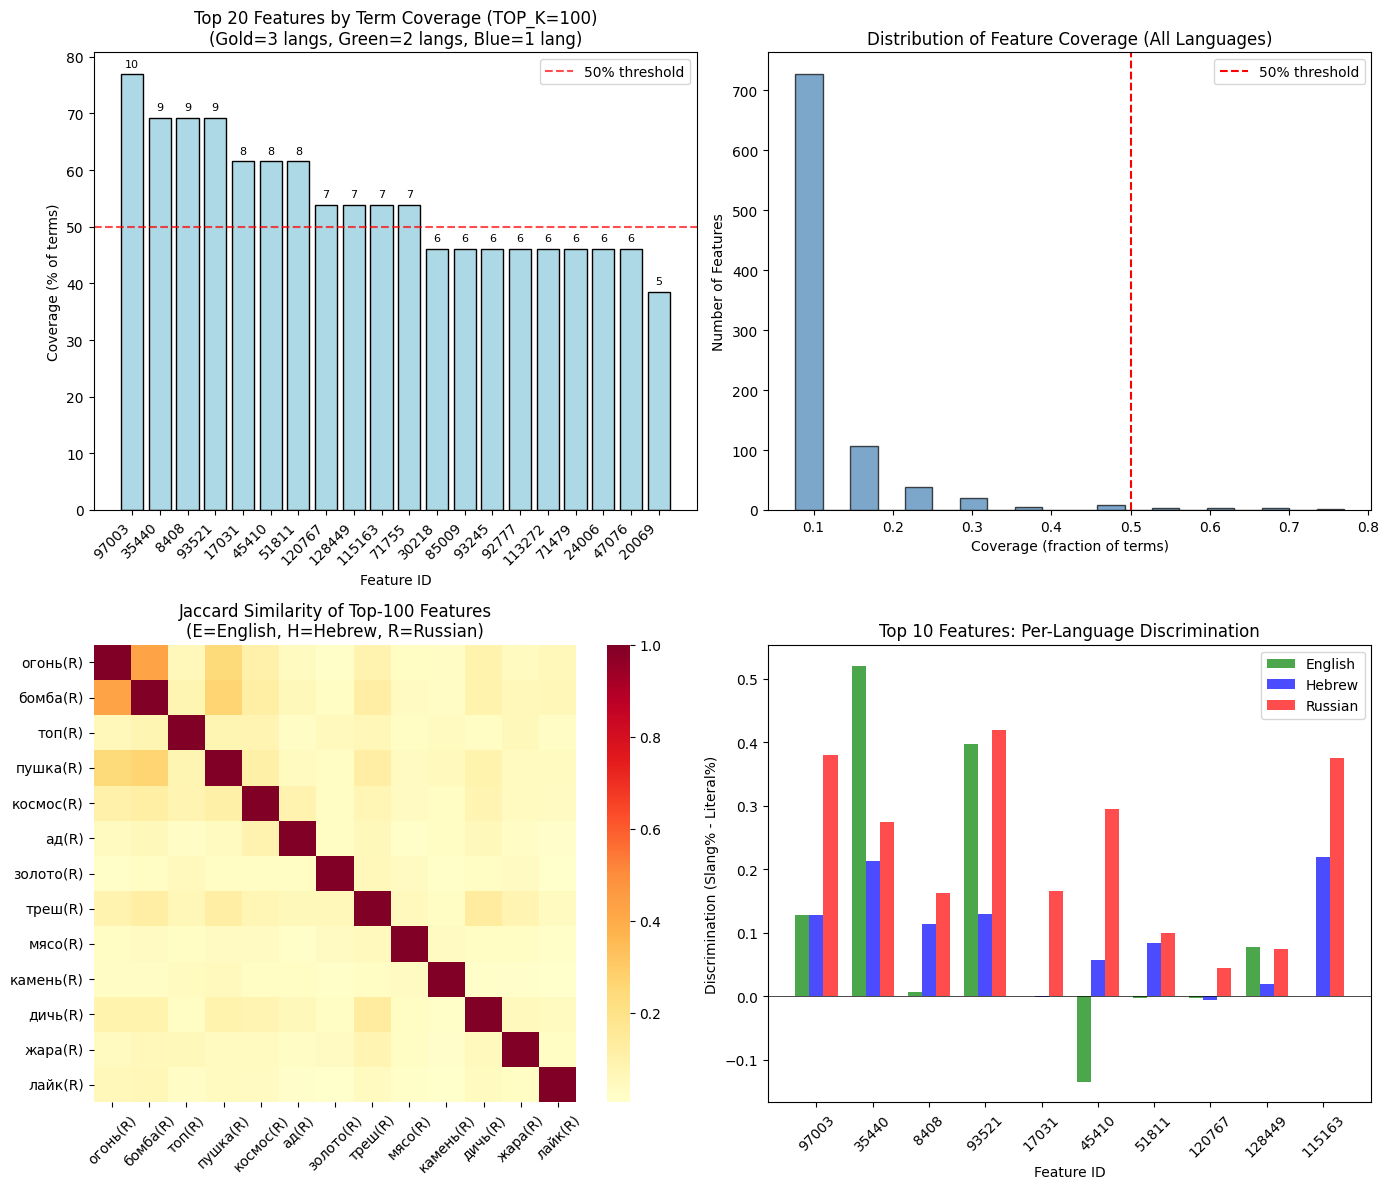


Saved: feature_intersection_analysis_layer20.png

FINAL SUMMARY (CROSS-LINGUISTIC)

PARAMETERS USED:
  - TOP_K_FEATURES: 100
  - Terms analyzed (all languages): 13
  - Terms by language: {'Russian': 13}
  - Total unique features: 917

FEATURE TIERS BY TERM COVERAGE:
  - Tier 1 (>50% coverage): 11 features
  - Tier 2 (30-50% coverage): 33 features

FEATURE DISTRIBUTION BY LANGUAGE COVERAGE:
  - Features in 3 languages: 0
  - Features in 2 languages: 0
  - Features in 1 language: 917

UNIVERSAL FEATURES (>50% coverage):
  [97003, 35440, 8408, 93521, 17031, 45410, 51811, 120767, 128449, 115163, 71755]

TRULY CROSS-LINGUISTIC (>30% coverage + all 3 languages):
  []

CROSS-VALIDATED FEATURES (intersection + metric analyses):
  [16371, 17031, 24006, 28165, 30218, 32283, 35440, 45410, 47076, 47195, 51811, 71479, 71755, 83575, 85009, 92777, 93521, 97003, 104622, 115163]
      
EXCLUSIVE PAIR OVERLAPS (>30% coverage):
  - Hebrew+Russian (not English): [8408, 30218, 45410, 51811, 72807, 104622,

In [ ]:
# ============================================================================
# ANALYSIS 5: FEATURE INTERSECTION ACROSS TARGET WORDS (CROSS-LINGUISTIC)
# ============================================================================

print("="*80)
print("ANALYSIS 5: FEATURE INTERSECTION ACROSS TARGET WORDS (ALL LANGUAGES)")
print("="*80)

from itertools import combinations
from collections import Counter

# ============================================================================
# Step 1: Setup - Get terms with sufficient examples (ALL LANGUAGES)
# ============================================================================

MIN_EXAMPLES = 3  # Minimum examples needed per category

terms_for_intersection = []
for term in slang_term_counts:
    slang_n = slang_term_counts[term]
    literal_n = literal_term_counts.get(term, 0)
    if slang_n >= MIN_EXAMPLES and literal_n >= MIN_EXAMPLES:
        terms_for_intersection.append(term)

print(f"Terms with >= {MIN_EXAMPLES} examples in both categories (all languages): {len(terms_for_intersection)}")

# Show breakdown by language
terms_by_lang = {'English': [], 'Hebrew': [], 'Russian': []}
for term in terms_for_intersection:
    for info in slang_term_info:
        if info['term'] == term:
            lang = info.get('language', 'Unknown')
            if lang in terms_by_lang and term not in terms_by_lang[lang]:
                terms_by_lang[lang].append(term)
            break

print(f"\nTerms by language:")
for lang, terms in terms_by_lang.items():
    print(f"  {lang}: {len(terms)} terms")

print(f"\nSample terms: {terms_for_intersection[:20]}{'...' if len(terms_for_intersection) > 20 else ''}\n")

n_terms = len(terms_for_intersection)

# ============================================================================
# Step 2: Function to extract top features for each term (CROSS-LINGUISTIC)
# ============================================================================

def extract_term_top_features(terms, top_k):
    """Extract top-K discriminative features for each term using combined cross-linguistic data."""
    term_top_features = {}
    term_feature_scores = {}
    term_languages = {}  # Track language for each term

    for term in terms:
        # Get indices from combined slang_term_info (all languages)
        slang_indices = [i for i, info in enumerate(slang_term_info) if info['term'] == term]
        literal_indices = [i for i, info in enumerate(literal_term_info) if info['term'] == term]

        if len(slang_indices) == 0 or len(literal_indices) == 0:
            continue

        # Get language for this term
        term_lang = slang_term_info[slang_indices[0]].get('language', 'Unknown') if slang_indices else 'Unknown'
        term_languages[term] = term_lang

        # Get features from combined tensors (all languages)
        term_slang_feats = slang_term_features[slang_indices]
        term_literal_feats = literal_term_features[literal_indices]

        # Calculate frequency difference
        slang_freq = (term_slang_feats > 0).float().mean(dim=0)
        literal_freq = (term_literal_feats > 0).float().mean(dim=0)
        freq_diff = slang_freq - literal_freq

        # Get top-k features
        top_k_result = torch.topk(freq_diff, k=top_k)
        term_top_features[term] = set(top_k_result.indices.tolist())
        term_feature_scores[term] = {idx.item(): score.item()
                                      for idx, score in zip(top_k_result.indices, top_k_result.values)}

    return term_top_features, term_feature_scores, term_languages

# ============================================================================
# Step 3: Function to find features appearing in at least N terms
# ============================================================================

def find_features_in_n_terms(term_top_features, min_terms):
    """Find features that appear in at least min_terms terms' top-K lists."""
    all_features_flat = []
    for term, features in term_top_features.items():
        all_features_flat.extend(features)

    feature_term_counts = Counter(all_features_flat)

    qualifying_features = {feat: count for feat, count in feature_term_counts.items()
                          if count >= min_terms}

    return qualifying_features

# ============================================================================
# Step 4: ITERATIVE SEARCH - Find optimal TOP_K and min_terms threshold
# ============================================================================

print("="*80)
print("ITERATIVE SEARCH FOR OPTIMAL PARAMETERS (CROSS-LINGUISTIC)")
print("="*80)

# Try different TOP_K values
TOP_K_VALUES = [100, 75, 50, 30, 20, 15, 10]

# Store results for each configuration
search_results = []

print(f"\n{'TOP_K':<8} {'Min Terms':<12} {'# Features':<12} {'Coverage':<12} {'Best Features'}")
print("-" * 80)

best_result = None
best_score = 0  # Score = num_features * coverage_fraction

for top_k in TOP_K_VALUES:
    # Extract features for this TOP_K
    term_top_features, term_feature_scores, term_languages = extract_term_top_features(terms_for_intersection, top_k)

    if len(term_top_features) < 2:
        continue

    n_valid_terms = len(term_top_features)

    # Try different minimum term thresholds (from ALL terms down to 2)
    for min_terms in range(n_valid_terms, 1, -1):
        qualifying_features = find_features_in_n_terms(term_top_features, min_terms)

        if len(qualifying_features) > 0:
            coverage = min_terms / n_valid_terms

            # Score: balance between number of features and coverage
            # We want features that appear in MANY terms
            score = len(qualifying_features) * coverage

            # Get top features by term count
            sorted_features = sorted(qualifying_features.items(), key=lambda x: x[1], reverse=True)
            top_3_features = [f[0] for f in sorted_features[:3]]

            result = {
                'top_k': top_k,
                'min_terms': min_terms,
                'n_features': len(qualifying_features),
                'coverage': coverage,
                'score': score,
                'features': qualifying_features,
                'term_top_features': term_top_features,
                'term_languages': term_languages
            }
            search_results.append(result)

            # Print interesting results (high coverage OR many features)
            if coverage >= 0.5 or len(qualifying_features) >= 10:
                print(f"{top_k:<8} {min_terms:<12} {len(qualifying_features):<12} "
                      f"{coverage:.1%}          {top_3_features}")

            # Track best result
            if score > best_score and coverage >= 0.3:  # At least 30% coverage
                best_score = score
                best_result = result

print("\n" + "="*80)
print("BEST CONFIGURATION FOUND")
print("="*80)

if best_result:
    print(f"\n  TOP_K = {best_result['top_k']}")
    print(f"  Min Terms = {best_result['min_terms']} / {len(best_result['term_top_features'])}")
    print(f"  Coverage = {best_result['coverage']:.1%}")
    print(f"  Features Found = {best_result['n_features']}")
    print(f"  Score = {best_result['score']:.2f}")

    # Use best configuration for subsequent analysis
    TOP_K_FEATURES = best_result['top_k']
    term_top_features = best_result['term_top_features']
    term_languages = best_result['term_languages']
    OPTIMAL_MIN_TERMS = best_result['min_terms']
else:
    print("\nNo good configuration found. Using defaults.")
    TOP_K_FEATURES = 20
    term_top_features, term_feature_scores, term_languages = extract_term_top_features(terms_for_intersection, TOP_K_FEATURES)
    OPTIMAL_MIN_TERMS = 2

# ============================================================================
# Step 5: DETAILED ANALYSIS OF FEATURES AT DIFFERENT COVERAGE LEVELS
# ============================================================================

print("\n" + "="*80)
print("FEATURE COVERAGE TIERS (CROSS-LINGUISTIC)")
print("="*80)
print(f"\nUsing TOP_K = {TOP_K_FEATURES}")

# Recalculate with best TOP_K
term_top_features, term_feature_scores, term_languages = extract_term_top_features(terms_for_intersection, TOP_K_FEATURES)
n_valid_terms = len(term_top_features)

# Show language breakdown of valid terms
lang_counts = Counter(term_languages.values())
print(f"\nValid terms by language: {dict(lang_counts)}")

# Count how many terms each feature appears in
all_features_flat = []
for term, features in term_top_features.items():
    all_features_flat.extend(features)
feature_term_counts = Counter(all_features_flat)

# Track which languages each feature appears in
feature_languages = {}
for feat in feature_term_counts.keys():
    langs = set()
    for term, features in term_top_features.items():
        if feat in features:
            langs.add(term_languages.get(term, 'Unknown'))
    feature_languages[feat] = langs

# Organize features into tiers
tier_definitions = [
    ("Tier 1 (>50% terms)", 0.50),
    ("Tier 2 (30-50% terms)", 0.30),
    ("Tier 3 (20-30% terms)", 0.20),
    ("Tier 4 (10-20% terms)", 0.10),
]

print(f"\nTotal terms analyzed (all languages): {n_valid_terms}")
print(f"Total unique features in any term's top-{TOP_K_FEATURES}: {len(feature_term_counts)}")

feature_tiers = {}

for tier_name, min_coverage in tier_definitions:
    min_term_count = int(n_valid_terms * min_coverage)
    max_term_count = int(n_valid_terms * (tier_definitions[tier_definitions.index((tier_name, min_coverage)) - 1][1]
                                          if tier_definitions.index((tier_name, min_coverage)) > 0 else 1.01))

    tier_features = {feat: count for feat, count in feature_term_counts.items()
                     if count >= min_term_count and count < max_term_count}

    if tier_name == tier_definitions[0][0]:  # First tier - no upper bound
        tier_features = {feat: count for feat, count in feature_term_counts.items()
                        if count >= min_term_count}

    feature_tiers[tier_name] = tier_features

    print(f"\n{tier_name}: {len(tier_features)} features (min {min_term_count} terms)")
    if tier_features:
        sorted_feats = sorted(tier_features.items(), key=lambda x: x[1], reverse=True)[:10]
        for feat, count in sorted_feats:
            coverage = count / n_valid_terms
            n_langs = len(feature_languages.get(feat, set()))
            langs_str = ','.join(sorted(feature_languages.get(feat, set())))
            print(f"    Feature {feat}: {count} terms ({coverage:.1%}), {n_langs} langs [{langs_str}]")

# ============================================================================
# Step 6: DETAILED TABLE OF UNIVERSAL FEATURES (Tier 1 & 2) - CROSS-LINGUISTIC
# ============================================================================

print("\n" + "="*80)
print("DETAILED ANALYSIS: HIGH-COVERAGE FEATURES (CROSS-LINGUISTIC)")
print("="*80)

# Combine Tier 1 and Tier 2
high_coverage_features = {**feature_tiers.get("Tier 1 (>50% terms)", {}),
                          **feature_tiers.get("Tier 2 (30-50% terms)", {})}

if high_coverage_features:
    # Calculate global metrics for these features (using combined cross-linguistic data)
    global_slang_freq = (slang_term_features > 0).float().mean(dim=0)
    global_literal_freq = (literal_term_features > 0).float().mean(dim=0)

    print(f"\n{'Feature':<10} {'Terms':<8} {'Cov':<8} {'#Lang':<6} {'Slang%':<9} {'Lit%':<9} {'Diff':<9} {'In Metrics'}")
    print("-" * 90)

    sorted_high_coverage = sorted(high_coverage_features.items(), key=lambda x: x[1], reverse=True)

    for feat_id, term_count in sorted_high_coverage:
        coverage = term_count / n_valid_terms
        s_freq = global_slang_freq[feat_id].item()
        l_freq = global_literal_freq[feat_id].item()
        diff = s_freq - l_freq
        n_langs = len(feature_languages.get(feat_id, set()))

        # Check if feature appears in our metric-based lists
        in_metrics = []
        if feat_id in TOP_PRECISION_FEATURES:
            in_metrics.append("Prec")
        if feat_id in TOP_RECALL_FEATURES:
            in_metrics.append("Rec")
        if feat_id in TOP_F1_FEATURES:
            in_metrics.append("F1")
        if feat_id in TOP_SPECIFICITY_FEATURES:
            in_metrics.append("Spec")

        in_metrics_str = ", ".join(in_metrics) if in_metrics else "-"

        print(f"{feat_id:<10} {term_count:<8} {coverage:.1%}    {n_langs:<6} {s_freq:.1%}     "
              f"{l_freq:.1%}     {diff:+.1%}    {in_metrics_str}")
else:
    print("\nNo features found with >30% coverage.")

# ============================================================================
# Step 6b: CROSS-LINGUISTIC VALIDATION OF HIGH-COVERAGE FEATURES
# ============================================================================

print("\n" + "="*80)
print("CROSS-LINGUISTIC VALIDATION OF HIGH-COVERAGE FEATURES")
print("="*80)

if high_coverage_features:
    print(f"\nChecking top features against per-language statistics...")
    print(f"\n{'Feature':<10} {'Eng Diff':<12} {'Heb Diff':<12} {'Rus Diff':<12} {'Avg Diff':<12} {'All Pos?':<10}")
    print("-" * 80)

    for feat_id in list(high_coverage_features.keys())[:20]:
        eng_diff = per_language_stats['English']['freq_diff'][feat_id].item()
        heb_diff = per_language_stats['Hebrew']['freq_diff'][feat_id].item()
        rus_diff = per_language_stats['Russian']['freq_diff'][feat_id].item()
        avg_diff = (eng_diff + heb_diff + rus_diff) / 3

        # Check if feature is consistently positive across all languages
        all_positive = eng_diff > 0 and heb_diff > 0 and rus_diff > 0
        consistent = "✓ Yes" if all_positive else "✗ No"

        print(f"{feat_id:<10} {eng_diff:+.1%}        {heb_diff:+.1%}        {rus_diff:+.1%}        {avg_diff:+.1%}        {consistent}")
# ============================================================================
# Step 6c: EXCLUSIVE PAIR VALIDATION OF HIGH-COVERAGE FEATURES
# ============================================================================

print("\n" + "="*80)
print("EXCLUSIVE PAIR VALIDATION OF HIGH-COVERAGE FEATURES")
print("="*80)

pair_configs = [
    ('Hebrew+Russian', HEBREW_RUSSIAN_FEATURES, 'English', ['Hebrew', 'Russian']),
    ('Hebrew+English', HEBREW_ENGLISH_FEATURES, 'Russian', ['Hebrew', 'English']),
    ('English+Russian', ENGLISH_RUSSIAN_FEATURES, 'Hebrew', ['English', 'Russian']),
]

for pair_name, pair_features, excluded, included in pair_configs:
    overlap_with_high_cov = set(high_coverage_features.keys()) & set(pair_features)

    print(f"\n{pair_name} (NOT in {excluded}):")
    print(f"  High-coverage features in this exclusive pair: {len(overlap_with_high_cov)}")

    if len(overlap_with_high_cov) > 0:
        print(f"\n  {'Feature':<10} {'Coverage':<10} {f'{included[0][:3]} Diff':<12} {f'{included[1][:3]} Diff':<12} {f'{excluded[:3]} Diff':<12}")
        print(f"  {'-'*60}")

        for feat_id in list(overlap_with_high_cov)[:10]:
            cov = high_coverage_features[feat_id] / n_valid_terms
            lang1_diff = per_language_stats[included[0]]['freq_diff'][feat_id].item()
            lang2_diff = per_language_stats[included[1]]['freq_diff'][feat_id].item()
            excl_diff = per_language_stats[excluded]['freq_diff'][feat_id].item()

            print(f"  {feat_id:<10} {cov:.1%}       {lang1_diff:+.1%}        {lang2_diff:+.1%}        {excl_diff:+.1%}")
# ============================================================================
# Step 7: FIND CORE FEATURE SET (Intersection approach) - CROSS-LINGUISTIC
# ============================================================================

print("\n" + "="*80)
print("CORE FEATURE SET SEARCH (Intersection of Multiple Terms, All Languages)")
print("="*80)

# Try to find the largest subset of terms that share features
print(f"\nSearching for feature sets shared by different numbers of terms...")
print(f"{'# Terms Required':<18} {'# Shared Features':<20} {'Example Features'}")
print("-" * 75)

core_feature_sets = {}

for required_terms in range(n_valid_terms, max(1, n_valid_terms // 4), -1):
    # Find features in at least 'required_terms' terms
    shared_features = {feat for feat, count in feature_term_counts.items()
                      if count >= required_terms}

    if shared_features:
        core_feature_sets[required_terms] = shared_features
        coverage = required_terms / n_valid_terms
        example_feats = list(shared_features)[:5]
        print(f"{required_terms:<18} {len(shared_features):<20} {example_feats}")

        # Stop once we find a reasonably sized set
        if len(shared_features) >= 3 and coverage < 1.0:
            break

# ============================================================================
# Step 8: COMPARE INTERSECTION FEATURES WITH METRIC-BASED FEATURES
# ============================================================================

print("\n" + "="*80)
print("CROSS-VALIDATION: Intersection vs Metric-Based Features")
print("="*80)

# Get features from intersection analysis (coverage > 30%)
intersection_features = set()
for feat, count in feature_term_counts.items():
    if count >= n_valid_terms * 0.30:
        intersection_features.add(feat)

# Compare with metric-based features
precision_set = set(TOP_PRECISION_FEATURES)
recall_set = set(TOP_RECALL_FEATURES)
f1_set = set(TOP_F1_FEATURES)
specificity_set = set(TOP_SPECIFICITY_FEATURES)

print(f"\nIntersection features (>30% coverage): {len(intersection_features)}")
print(f"TOP_PRECISION_FEATURES: {len(precision_set)}")
print(f"TOP_RECALL_FEATURES: {len(recall_set)}")
print(f"TOP_F1_FEATURES: {len(f1_set)}")
print(f"TOP_SPECIFICITY_FEATURES: {len(specificity_set)}")

print(f"\nOverlaps:")
print(f"  Intersection ∩ Precision: {intersection_features & precision_set}")
print(f"  Intersection ∩ Recall: {intersection_features & recall_set}")
print(f"  Intersection ∩ F1: {intersection_features & f1_set}")
print(f"  Intersection ∩ Specificity: {intersection_features & specificity_set}")

# Features that appear in BOTH intersection AND metric-based analysis
universal_validated = intersection_features & (precision_set | recall_set | f1_set | specificity_set)
print(f"\n★ VALIDATED UNIVERSAL FEATURES (in both analyses): {sorted(universal_validated)}")

# Also check overlap with cross-linguistic universal features from Cell 9
if 'UNIVERSAL_LAYER20_FEATURES' in dir() and UNIVERSAL_LAYER20_FEATURES:
    crossling_overlap = intersection_features & set(UNIVERSAL_LAYER20_FEATURES)
    print(f"\n★ OVERLAP WITH CROSS-LINGUISTIC UNIVERSAL FEATURES (from Cell 9): {sorted(crossling_overlap)}")

# Identify features that appear in ALL 3 languages
truly_crossling_features = {feat for feat, langs in feature_languages.items()
                            if len(langs) == 3 and feat in intersection_features}
print(f"\n★ TRULY CROSS-LINGUISTIC FEATURES (>30% coverage + all 3 languages): {sorted(truly_crossling_features)}")
# Check overlap with exclusive pair features
print(f"\nOverlaps with Exclusive Pairs:")
hr_overlap = intersection_features & set(HEBREW_RUSSIAN_FEATURES)
he_overlap = intersection_features & set(HEBREW_ENGLISH_FEATURES)
er_overlap = intersection_features & set(ENGLISH_RUSSIAN_FEATURES)
print(f"  Intersection ∩ Hebrew+Russian (not Eng): {sorted(hr_overlap)}")
print(f"  Intersection ∩ Hebrew+English (not Rus): {sorted(he_overlap)}")
print(f"  Intersection ∩ English+Russian (not Heb): {sorted(er_overlap)}")
# ============================================================================
# Step 9: VISUALIZATION (CROSS-LINGUISTIC)
# ============================================================================

print("\n" + "="*80)
print("CREATING VISUALIZATIONS (CROSS-LINGUISTIC)")
print("="*80)

import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Bar chart of top features by coverage (colored by language count)
ax1 = axes[0, 0]
top_features_by_coverage = sorted(feature_term_counts.items(), key=lambda x: x[1], reverse=True)[:20]
feat_ids = [str(f[0]) for f in top_features_by_coverage]
term_counts_plot = [f[1] for f in top_features_by_coverage]
coverages = [c / n_valid_terms * 100 for c in term_counts_plot]
lang_counts_plot = [len(feature_languages.get(f[0], set())) for f in top_features_by_coverage]

# Color by number of languages
colors = ['gold' if lc == 3 else 'lightgreen' if lc == 2 else 'lightblue' for lc in lang_counts_plot]

bars = ax1.bar(range(len(feat_ids)), coverages, color=colors, edgecolor='black')
ax1.set_xticks(range(len(feat_ids)))
ax1.set_xticklabels(feat_ids, rotation=45, ha='right')
ax1.set_xlabel('Feature ID')
ax1.set_ylabel('Coverage (% of terms)')
ax1.set_title(f'Top 20 Features by Term Coverage (TOP_K={TOP_K_FEATURES})\n(Gold=3 langs, Green=2 langs, Blue=1 lang)')
ax1.axhline(y=50, color='red', linestyle='--', alpha=0.7, label='50% threshold')
ax1.legend()

# Add term count labels
for bar, count in zip(bars, term_counts_plot):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{count}', ha='center', va='bottom', fontsize=8)

# Histogram of feature coverage
ax2 = axes[0, 1]
all_coverages = [count / n_valid_terms for count in feature_term_counts.values()]
ax2.hist(all_coverages, bins=20, color='steelblue', edgecolor='black', alpha=0.7)
ax2.set_xlabel('Coverage (fraction of terms)')
ax2.set_ylabel('Number of Features')
ax2.set_title('Distribution of Feature Coverage (All Languages)')
ax2.axvline(x=0.5, color='red', linestyle='--', label='50% threshold')
ax2.legend()

# Heatmap of pairwise Jaccard similarity (subsample if too many terms)
ax3 = axes[1, 0]
terms_to_plot = terms_for_intersection[:min(20, len(terms_for_intersection))]
n_plot = len(terms_to_plot)
jaccard_matrix = np.zeros((n_plot, n_plot))

for i, term1 in enumerate(terms_to_plot):
    for j, term2 in enumerate(terms_to_plot):
        if i == j:
            jaccard_matrix[i, j] = 1.0
        elif term1 in term_top_features and term2 in term_top_features:
            features1 = term_top_features[term1]
            features2 = term_top_features[term2]
            intersection_jac = features1 & features2
            union_jac = features1 | features2
            jaccard_matrix[i, j] = len(intersection_jac) / len(union_jac) if union_jac else 0

# Create labels with language info
term_labels = [f"{t[:8]}({term_languages.get(t, '?')[0]})" for t in terms_to_plot]

sns.heatmap(jaccard_matrix, xticklabels=term_labels, yticklabels=term_labels,
            annot=True if n_plot <= 10 else False, fmt='.2f', cmap='YlOrRd', ax=ax3)
ax3.set_title(f'Jaccard Similarity of Top-{TOP_K_FEATURES} Features\n(E=English, H=Hebrew, R=Russian)')
ax3.tick_params(axis='x', rotation=45)

# Per-language discrimination for top features
ax4 = axes[1, 1]
top_10_feats = [f[0] for f in top_features_by_coverage[:10]]

x = np.arange(len(top_10_feats))
width = 0.25

eng_diffs = [per_language_stats['English']['freq_diff'][f].item() for f in top_10_feats]
heb_diffs = [per_language_stats['Hebrew']['freq_diff'][f].item() for f in top_10_feats]
rus_diffs = [per_language_stats['Russian']['freq_diff'][f].item() for f in top_10_feats]

ax4.bar(x - width, eng_diffs, width, label='English', color='green', alpha=0.7)
ax4.bar(x, heb_diffs, width, label='Hebrew', color='blue', alpha=0.7)
ax4.bar(x + width, rus_diffs, width, label='Russian', color='red', alpha=0.7)

ax4.set_xlabel('Feature ID')
ax4.set_ylabel('Discrimination (Slang% - Literal%)')
ax4.set_title('Top 10 Features: Per-Language Discrimination')
ax4.set_xticks(x)
ax4.set_xticklabels(top_10_feats, rotation=45)
ax4.legend()
ax4.axhline(y=0, color='black', linestyle='-', linewidth=0.5)

plt.tight_layout()
plt.savefig('/content/feature_intersection_analysis_layer20.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nSaved: feature_intersection_analysis_layer20.png")

# ============================================================================
# Step 10: FINAL SUMMARY AND SAVED OUTPUTS (CROSS-LINGUISTIC)
# ============================================================================

print("\n" + "="*80)
print("FINAL SUMMARY (CROSS-LINGUISTIC)")
print("="*80)

# Determine the final "universal" feature set
UNIVERSAL_FEATURES_BY_COVERAGE = sorted([feat for feat, count in feature_term_counts.items()
                                          if count >= n_valid_terms * 0.5],
                                         key=lambda x: feature_term_counts[x], reverse=True)

SEMI_UNIVERSAL_FEATURES = sorted([feat for feat, count in feature_term_counts.items()
                                   if n_valid_terms * 0.3 <= count < n_valid_terms * 0.5],
                                  key=lambda x: feature_term_counts[x], reverse=True)

# Count features by language coverage
features_3_langs = [f for f, langs in feature_languages.items() if len(langs) == 3]
features_2_langs = [f for f, langs in feature_languages.items() if len(langs) == 2]
features_1_lang = [f for f, langs in feature_languages.items() if len(langs) == 1]

print(f"""
PARAMETERS USED:
  - TOP_K_FEATURES: {TOP_K_FEATURES}
  - Terms analyzed (all languages): {n_valid_terms}
  - Terms by language: {dict(lang_counts)}
  - Total unique features: {len(feature_term_counts)}

FEATURE TIERS BY TERM COVERAGE:
  - Tier 1 (>50% coverage): {len(UNIVERSAL_FEATURES_BY_COVERAGE)} features
  - Tier 2 (30-50% coverage): {len(SEMI_UNIVERSAL_FEATURES)} features

FEATURE DISTRIBUTION BY LANGUAGE COVERAGE:
  - Features in 3 languages: {len(features_3_langs)}
  - Features in 2 languages: {len(features_2_langs)}
  - Features in 1 language: {len(features_1_lang)}

UNIVERSAL FEATURES (>50% coverage):
  {UNIVERSAL_FEATURES_BY_COVERAGE}

TRULY CROSS-LINGUISTIC (>30% coverage + all 3 languages):
  {sorted(truly_crossling_features)}

CROSS-VALIDATED FEATURES (intersection + metric analyses):
  {sorted(universal_validated)}

EXCLUSIVE PAIR OVERLAPS (>30% coverage):
  - Hebrew+Russian (not English): {sorted(intersection_features & set(HEBREW_RUSSIAN_FEATURES))}
  - Hebrew+English (not Russian): {sorted(intersection_features & set(HEBREW_ENGLISH_FEATURES))}
  - English+Russian (not Hebrew): {sorted(intersection_features & set(ENGLISH_RUSSIAN_FEATURES))}

STATISTICS:
  - Average pairwise Jaccard: {np.mean(jaccard_matrix[np.triu_indices_from(jaccard_matrix, k=1)]):.3f}
  - Features in only 1 term: {sum(1 for c in feature_term_counts.values() if c == 1)}
  - Features in 2+ terms: {sum(1 for c in feature_term_counts.values() if c >= 2)}
""")

# Save all results
INTERSECTION_ANALYSIS_RESULTS = {
    'top_k_used': TOP_K_FEATURES,
    'n_terms': n_valid_terms,
    'terms_analyzed': list(term_top_features.keys()),
    'terms_by_language': {lang: list(terms) for lang, terms in terms_by_lang.items()},
    'feature_term_counts': dict(feature_term_counts),
    'feature_languages': {k: list(v) for k, v in feature_languages.items()},
    'universal_features_50pct': UNIVERSAL_FEATURES_BY_COVERAGE,
    'semi_universal_features_30pct': SEMI_UNIVERSAL_FEATURES,
    'truly_crossling_features': sorted(truly_crossling_features),
    'cross_validated_features': sorted(universal_validated),
    'term_top_features': {k: list(v) for k, v in term_top_features.items()},
    'term_languages': term_languages,
    'jaccard_matrix': jaccard_matrix,
    'search_results': search_results,
    'exclusive_pair_overlaps': {
        'hebrew_russian': sorted(intersection_features & set(HEBREW_RUSSIAN_FEATURES)),
        'hebrew_english': sorted(intersection_features & set(HEBREW_ENGLISH_FEATURES)),
        'english_russian': sorted(intersection_features & set(ENGLISH_RUSSIAN_FEATURES))
    },
}

print("✓ Results saved to 'INTERSECTION_ANALYSIS_RESULTS' dictionary")

# Create final feature list combining all evidence
FINAL_SLANG_FEATURES = sorted(set(UNIVERSAL_FEATURES_BY_COVERAGE) | universal_validated | truly_crossling_features)
print(f"\n★ FINAL RECOMMENDED SLANG FEATURES (CROSS-LINGUISTIC): {FINAL_SLANG_FEATURES}")

# Also create pair-specific feature recommendations
PAIR_SPECIFIC_FEATURES = {
    'Hebrew+Russian': sorted(set(HEBREW_RUSSIAN_FEATURES) & intersection_features),
    'Hebrew+English': sorted(set(HEBREW_ENGLISH_FEATURES) & intersection_features),
    'English+Russian': sorted(set(ENGLISH_RUSSIAN_FEATURES) & intersection_features)
}
print(f"\n★ PAIR-SPECIFIC VALIDATED FEATURES:")
for pair_name, feats in PAIR_SPECIFIC_FEATURES.items():
    print(f"  {pair_name}: {feats if feats else 'None'}")

print("\n" + "="*80)

In [ ]:
# ============================================================================
# CELL 19: EXPORT COMPREHENSIVE SLANG FEATURES JSON
# ============================================================================

import json

print("="*80)
print("EXPORTING COMPREHENSIVE SLANG FEATURES JSON")
print("="*80)

# ============================================================================
# Collect all feature data organized by language groupings
# ============================================================================

def get_feature_details(feat_idx):
    """Get comprehensive details for a single feature."""
    details = {
        'feature_id': feat_idx,
        'per_language_stats': {},
        'combined_stats': {},
        'coverage_info': {},
        'strength_info': {}
    }

    # Per-language statistics
    for lang in ['English', 'Hebrew', 'Russian']:
        slang_freq = per_language_stats[lang]['slang_freq'][feat_idx].item()
        literal_freq = per_language_stats[lang]['literal_freq'][feat_idx].item()
        diff = slang_freq - literal_freq

        details['per_language_stats'][lang] = {
            'slang_frequency': round(slang_freq, 4),
            'literal_frequency': round(literal_freq, 4),
            'discrimination': round(diff, 4),
            'in_top_100': feat_idx in lang_top_features.get(lang, set())
        }

    # Combined statistics (all languages)
    global_slang_freq = (slang_term_features > 0).float().mean(dim=0)[feat_idx].item()
    global_literal_freq = (literal_term_features > 0).float().mean(dim=0)[feat_idx].item()

    details['combined_stats'] = {
        'slang_frequency': round(global_slang_freq, 4),
        'literal_frequency': round(global_literal_freq, 4),
        'discrimination': round(global_slang_freq - global_literal_freq, 4)
    }

    # Coverage info from intersection analysis
    if feat_idx in feature_term_counts:
        details['coverage_info'] = {
            'term_count': feature_term_counts[feat_idx],
            'coverage_pct': round(feature_term_counts[feat_idx] / n_valid_terms, 4),
            'languages_present': list(feature_languages.get(feat_idx, set()))
        }

    # Strength info if available
    if feat_idx in feature_strength_summary:
        strength = feature_strength_summary[feat_idx]
        details['strength_info'] = {
            'avg_discrimination': round(strength['avg_discrimination'], 4),
            'avg_slang_activation': round(strength['avg_slang_activation'], 4),
            'coverage_x_discrimination': round(strength['coverage_x_discrimination'], 4),
            'n_languages': strength['n_languages']
        }

    # Check membership in key feature lists
    details['memberships'] = {
        'in_precision_top': feat_idx in TOP_PRECISION_FEATURES,
        'in_recall_top': feat_idx in TOP_RECALL_FEATURES,
        'in_f1_top': feat_idx in TOP_F1_FEATURES,
        'in_specificity_top': feat_idx in TOP_SPECIFICITY_FEATURES,
        'in_best_features': feat_idx in BEST_FEATURES if BEST_FEATURES else False,
        'in_final_recommended': feat_idx in FINAL_SLANG_FEATURES
    }

    return details

# ============================================================================
# Build the comprehensive JSON structure
# ============================================================================

print("\nCollecting feature data for all language groupings...")

slang_features_json = {
    'metadata': {
        'layer': 20,
        'top_k_used': TOP_K,
        'total_terms_analyzed': n_valid_terms,
        'languages': ['English', 'Hebrew', 'Russian'],
        'export_date': str(pd.Timestamp.now()) if 'pd' in dir() else 'N/A'
    },
    'feature_groups': {}
}

# ============================================================================
# 1. UNIVERSAL: English + Hebrew + Russian (all 3 languages)
# ============================================================================

universal_features = list(set(UNIVERSAL_LAYER20_FEATURES) | set(tier_3_lang) | truly_crossling_features)
universal_features = sorted(set(universal_features))

print(f"\n1. Universal (Eng+Heb+Rus): {len(universal_features)} features")

slang_features_json['feature_groups']['English_Hebrew_Russian'] = {
    'description': 'Features discriminative for slang in ALL 3 languages',
    'n_features': len(universal_features),
    'feature_ids': universal_features,
    'features': [get_feature_details(f) for f in universal_features]
}

# ============================================================================
# 2. EXCLUSIVE PAIRS (A+B but NOT C)
# ============================================================================

# Hebrew + English (NOT Russian)
he_features = sorted(set(HEBREW_ENGLISH_FEATURES))
print(f"2. Hebrew+English (not Rus): {len(he_features)} features")

slang_features_json['feature_groups']['Hebrew_English'] = {
    'description': 'Features discriminative for slang in Hebrew AND English, but NOT Russian',
    'excluded_language': 'Russian',
    'n_features': len(he_features),
    'feature_ids': he_features,
    'features': [get_feature_details(f) for f in he_features]
}

# Hebrew + Russian (NOT English)
hr_features = sorted(set(HEBREW_RUSSIAN_FEATURES))
print(f"3. Hebrew+Russian (not Eng): {len(hr_features)} features")

slang_features_json['feature_groups']['Hebrew_Russian'] = {
    'description': 'Features discriminative for slang in Hebrew AND Russian, but NOT English',
    'excluded_language': 'English',
    'n_features': len(hr_features),
    'feature_ids': hr_features,
    'features': [get_feature_details(f) for f in hr_features]
}

# English + Russian (NOT Hebrew)
er_features = sorted(set(ENGLISH_RUSSIAN_FEATURES))
print(f"4. English+Russian (not Heb): {len(er_features)} features")

slang_features_json['feature_groups']['English_Russian'] = {
    'description': 'Features discriminative for slang in English AND Russian, but NOT Hebrew',
    'excluded_language': 'Hebrew',
    'n_features': len(er_features),
    'feature_ids': er_features,
    'features': [get_feature_details(f) for f in er_features]
}

# ============================================================================
# 3. LANGUAGE-SPECIFIC (only in 1 language)
# ============================================================================

# English only
english_only = sorted([f for f in lang_top_features['English']
                       if feature_language_count[f] == 1])
print(f"5. English only: {len(english_only)} features")

slang_features_json['feature_groups']['English'] = {
    'description': 'Features discriminative for slang ONLY in English',
    'n_features': len(english_only),
    'feature_ids': english_only,
    'features': [get_feature_details(f) for f in english_only]
}

# Hebrew only
hebrew_only = sorted([f for f in lang_top_features['Hebrew']
                      if feature_language_count[f] == 1])
print(f"6. Hebrew only: {len(hebrew_only)} features")

slang_features_json['feature_groups']['Hebrew'] = {
    'description': 'Features discriminative for slang ONLY in Hebrew',
    'n_features': len(hebrew_only),
    'feature_ids': hebrew_only,
    'features': [get_feature_details(f) for f in hebrew_only]
}

# Russian only
russian_only = sorted([f for f in lang_top_features['Russian']
                       if feature_language_count[f] == 1])
print(f"7. Russian only: {len(russian_only)} features")

slang_features_json['feature_groups']['Russian'] = {
    'description': 'Features discriminative for slang ONLY in Russian',
    'n_features': len(russian_only),
    'feature_ids': russian_only,
    'features': [get_feature_details(f) for f in russian_only]
}

# ============================================================================
# Add summary statistics
# ============================================================================

slang_features_json['summary'] = {
    'total_unique_features': len(set(
        universal_features + he_features + hr_features + er_features +
        english_only + hebrew_only + russian_only
    )),
    'by_group': {
        'universal_3_langs': len(universal_features),
        'hebrew_english_pair': len(he_features),
        'hebrew_russian_pair': len(hr_features),
        'english_russian_pair': len(er_features),
        'english_only': len(english_only),
        'hebrew_only': len(hebrew_only),
        'russian_only': len(russian_only)
    },
    'recommended_features': {
        'final_recommended': FINAL_SLANG_FEATURES,
        'best_by_strength': BEST_FEATURES[:20] if BEST_FEATURES else [],
        'cross_validated': sorted(universal_validated) if 'universal_validated' in dir() else []
    }
}

# ============================================================================
# Save JSON file
# ============================================================================

json_path = '/content/slang_features_layer20_comprehensive.json'

with open(json_path, 'w', encoding='utf-8') as f:
    json.dump(slang_features_json, f, indent=2, ensure_ascii=False)

print(f"\n{'='*80}")
print("JSON EXPORT COMPLETE")
print(f"{'='*80}")
print(f"\n✓ Saved to: {json_path}")

# Print structure summary
print(f"\nJSON Structure:")
print(f"  - metadata: layer, parameters, date")
print(f"  - feature_groups:")
print(f"      • English_Hebrew_Russian: {len(universal_features)} features (universal)")
print(f"      • Hebrew_English: {len(he_features)} features (not in Russian)")
print(f"      • Hebrew_Russian: {len(hr_features)} features (not in English)")
print(f"      • English_Russian: {len(er_features)} features (not in Hebrew)")
print(f"      • English: {len(english_only)} features (English only)")
print(f"      • Hebrew: {len(hebrew_only)} features (Hebrew only)")
print(f"      • Russian: {len(russian_only)} features (Russian only)")
print(f"  - summary: totals and recommended features")

print(f"\nTotal features exported: {slang_features_json['summary']['total_unique_features']}")

# ============================================================================
# Download the file (for Colab)
# ============================================================================

try:
    from google.colab import files
    files.download(json_path)
    print(f"\n✓ Download initiated for: {json_path}")
except ImportError:
    print(f"\n(Not in Colab - file saved to {json_path})")

print("\n" + "="*80)

EXPORTING COMPREHENSIVE SLANG FEATURES JSON


1. Universal (Eng+Heb+Rus): 10 features
2. Hebrew+English (not Rus): 5 features
3. Hebrew+Russian (not Eng): 13 features
4. English+Russian (not Heb): 11 features
5. English only: 74 features
6. Hebrew only: 72 features
7. Russian only: 66 features

JSON EXPORT COMPLETE

✓ Saved to: /content/slang_features_layer20_comprehensive.json

JSON Structure:
  - metadata: layer, parameters, date
  - feature_groups:
      • English_Hebrew_Russian: 10 features (universal)
      • Hebrew_English: 5 features (not in Russian)
      • Hebrew_Russian: 13 features (not in English)
      • English_Russian: 11 features (not in Hebrew)
      • English: 74 features (English only)
      • Hebrew: 72 features (Hebrew only)
      • Russian: 66 features (Russian only)
  - summary: totals and recommended features

Total features exported: 251


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✓ Download initiated for: /content/slang_features_layer20_comprehensive.json



In [ ]:
# ============================================================================
# CELL 19: EXPORT COMPREHENSIVE SLANG FEATURES JSON FOR STEERING EXPERIMENTS
# ============================================================================

import json

print("="*80)
print("EXPORTING COMPREHENSIVE SLANG FEATURES JSON FOR STEERING EXPERIMENTS")
print("="*80)

# ============================================================================
# Helper function to get detailed feature statistics
# ============================================================================

def get_feature_details(feat_idx):
    """Get comprehensive details for a single feature."""
    details = {
        'feature_id': int(feat_idx),
        'per_language_stats': {},
        'combined_stats': {},
        'coverage_info': {},
        'strength_info': {},
        'memberships': {}
    }

    # Per-language statistics
    for lang in ['English', 'Hebrew', 'Russian']:
        slang_freq = per_language_stats[lang]['slang_freq'][feat_idx].item()
        literal_freq = per_language_stats[lang]['literal_freq'][feat_idx].item()
        diff = slang_freq - literal_freq

        details['per_language_stats'][lang] = {
            'slang_frequency': round(slang_freq, 4),
            'literal_frequency': round(literal_freq, 4),
            'discrimination': round(diff, 4),
            'in_top_100': feat_idx in lang_top_features.get(lang, set())
        }

    # Combined statistics (all languages)
    global_slang_freq = (slang_term_features > 0).float().mean(dim=0)[feat_idx].item()
    global_literal_freq = (literal_term_features > 0).float().mean(dim=0)[feat_idx].item()

    details['combined_stats'] = {
        'slang_frequency': round(global_slang_freq, 4),
        'literal_frequency': round(global_literal_freq, 4),
        'discrimination': round(global_slang_freq - global_literal_freq, 4)
    }

    # Coverage info from intersection analysis
    if 'feature_term_counts' in dir() and feat_idx in feature_term_counts:
        details['coverage_info'] = {
            'term_count': int(feature_term_counts[feat_idx]),
            'coverage_pct': round(feature_term_counts[feat_idx] / n_valid_terms, 4) if n_valid_terms > 0 else 0,
            'languages_present': list(feature_languages.get(feat_idx, set())) if 'feature_languages' in dir() else []
        }

    # Strength info if available
    if 'feature_strength_summary' in dir() and feat_idx in feature_strength_summary:
        strength = feature_strength_summary[feat_idx]
        details['strength_info'] = {
            'avg_discrimination': round(strength['avg_discrimination'], 4),
            'avg_slang_activation': round(strength['avg_slang_activation'], 4),
            'avg_literal_activation': round(strength['avg_literal_activation'], 4),
            'coverage_x_discrimination': round(strength['coverage_x_discrimination'], 4),
            'n_languages': int(strength['n_languages']),
            'consistency_score': round(strength.get('consistency_score', 0), 4)
        }

    # Check membership in key feature lists
    details['memberships'] = {
        'in_precision_top': feat_idx in TOP_PRECISION_FEATURES if 'TOP_PRECISION_FEATURES' in dir() else False,
        'in_recall_top': feat_idx in TOP_RECALL_FEATURES if 'TOP_RECALL_FEATURES' in dir() else False,
        'in_f1_top': feat_idx in TOP_F1_FEATURES if 'TOP_F1_FEATURES' in dir() else False,
        'in_specificity_top': feat_idx in TOP_SPECIFICITY_FEATURES if 'TOP_SPECIFICITY_FEATURES' in dir() else False,
        'in_best_features': feat_idx in BEST_FEATURES if 'BEST_FEATURES' in dir() and BEST_FEATURES else False,
        'in_final_recommended': feat_idx in FINAL_SLANG_FEATURES if 'FINAL_SLANG_FEATURES' in dir() else False
    }

    return details

def get_feature_list_with_stats(feature_list):
    """Get list of features with their full statistics."""
    return [get_feature_details(f) for f in sorted(feature_list)]

# ============================================================================
# Build the comprehensive JSON structure
# ============================================================================

print("\nCollecting feature data for all language groupings...")

slang_features_json = {
    'metadata': {
        'layer': 20,
        'top_k_used': TOP_K,
        'total_terms_analyzed': n_valid_terms if 'n_valid_terms' in dir() else 0,
        'languages': ['English', 'Hebrew', 'Russian'],
        'description': 'Comprehensive slang feature data for steering experiments',
        'usage_guide': {
            'universal_3_langs': 'Use for experiments targeting ALL languages simultaneously',
            'exclusive_pairs': 'Use for experiments targeting exactly 2 languages (feature is NOT discriminative in third)',
            'language_specific': 'Use for experiments targeting only ONE language',
            'union_sets': 'Use for experiments that should affect AT LEAST the specified languages',
            'intersection_sets': 'Validated features appearing in multiple analyses'
        }
    },

    # ========================================================================
    # SECTION 1: UNIVERSAL FEATURES (All 3 languages)
    # ========================================================================
    'universal_all_three': {
        'description': 'Features discriminative for slang in ALL 3 languages (English, Hebrew, Russian)',
        'use_case': 'Steering that should affect slang detection across all languages',
        'feature_ids': sorted(list(set(UNIVERSAL_LAYER20_FEATURES) | set(tier_3_lang))),
        'n_features': len(set(UNIVERSAL_LAYER20_FEATURES) | set(tier_3_lang)),
        'features': get_feature_list_with_stats(set(UNIVERSAL_LAYER20_FEATURES) | set(tier_3_lang))
    },

    # ========================================================================
    # SECTION 2: EXCLUSIVE PAIRS (A+B but NOT C)
    # ========================================================================
    'exclusive_pairs': {
        'Hebrew_Russian_not_English': {
            'description': 'Features discriminative in Hebrew AND Russian, but NOT in English',
            'included_languages': ['Hebrew', 'Russian'],
            'excluded_language': 'English',
            'use_case': 'Steering that should affect Hebrew and Russian but NOT English',
            'feature_ids': sorted(HEBREW_RUSSIAN_FEATURES),
            'n_features': len(HEBREW_RUSSIAN_FEATURES),
            'features': get_feature_list_with_stats(HEBREW_RUSSIAN_FEATURES)
        },
        'Hebrew_English_not_Russian': {
            'description': 'Features discriminative in Hebrew AND English, but NOT in Russian',
            'included_languages': ['Hebrew', 'English'],
            'excluded_language': 'Russian',
            'use_case': 'Steering that should affect Hebrew and English but NOT Russian',
            'feature_ids': sorted(HEBREW_ENGLISH_FEATURES),
            'n_features': len(HEBREW_ENGLISH_FEATURES),
            'features': get_feature_list_with_stats(HEBREW_ENGLISH_FEATURES)
        },
        'English_Russian_not_Hebrew': {
            'description': 'Features discriminative in English AND Russian, but NOT in Hebrew',
            'included_languages': ['English', 'Russian'],
            'excluded_language': 'Hebrew',
            'use_case': 'Steering that should affect English and Russian but NOT Hebrew',
            'feature_ids': sorted(ENGLISH_RUSSIAN_FEATURES),
            'n_features': len(ENGLISH_RUSSIAN_FEATURES),
            'features': get_feature_list_with_stats(ENGLISH_RUSSIAN_FEATURES)
        }
    },

    # ========================================================================
    # SECTION 3: LANGUAGE-SPECIFIC (Only 1 language)
    # ========================================================================
    'language_specific': {
        'English_only': {
            'description': 'Features discriminative ONLY in English (not in Hebrew or Russian top-100)',
            'use_case': 'Steering that should affect ONLY English slang detection',
            'feature_ids': sorted([f for f in lang_top_features['English'] if feature_language_count[f] == 1]),
            'n_features': len([f for f in lang_top_features['English'] if feature_language_count[f] == 1]),
            'top_5_by_discrimination': sorted(
                [f for f in lang_top_features['English'] if feature_language_count[f] == 1],
                key=lambda f: per_language_stats['English']['freq_diff'][f].item(),
                reverse=True
            )[:5],
            'features': get_feature_list_with_stats([f for f in lang_top_features['English'] if feature_language_count[f] == 1])
        },
        'Hebrew_only': {
            'description': 'Features discriminative ONLY in Hebrew (not in English or Russian top-100)',
            'use_case': 'Steering that should affect ONLY Hebrew slang detection',
            'feature_ids': sorted([f for f in lang_top_features['Hebrew'] if feature_language_count[f] == 1]),
            'n_features': len([f for f in lang_top_features['Hebrew'] if feature_language_count[f] == 1]),
            'top_5_by_discrimination': sorted(
                [f for f in lang_top_features['Hebrew'] if feature_language_count[f] == 1],
                key=lambda f: per_language_stats['Hebrew']['freq_diff'][f].item(),
                reverse=True
            )[:5],
            'features': get_feature_list_with_stats([f for f in lang_top_features['Hebrew'] if feature_language_count[f] == 1])
        },
        'Russian_only': {
            'description': 'Features discriminative ONLY in Russian (not in English or Hebrew top-100)',
            'use_case': 'Steering that should affect ONLY Russian slang detection',
            'feature_ids': sorted([f for f in lang_top_features['Russian'] if feature_language_count[f] == 1]),
            'n_features': len([f for f in lang_top_features['Russian'] if feature_language_count[f] == 1]),
            'top_5_by_discrimination': sorted(
                [f for f in lang_top_features['Russian'] if feature_language_count[f] == 1],
                key=lambda f: per_language_stats['Russian']['freq_diff'][f].item(),
                reverse=True
            )[:5],
            'features': get_feature_list_with_stats([f for f in lang_top_features['Russian'] if feature_language_count[f] == 1])
        }
    },

    # ========================================================================
    # SECTION 4: UNION SETS (at least these languages)
    # ========================================================================
    'union_sets': {
        'description': 'Features that are discriminative in AT LEAST the specified languages (may also work in others)',

        'English_or_Hebrew_or_Russian': {
            'description': 'ALL features in top-100 for ANY language (full feature pool)',
            'use_case': 'Maximum coverage - any slang-related feature',
            'feature_ids': sorted(list(lang_top_features['English'] | lang_top_features['Hebrew'] | lang_top_features['Russian'])),
            'n_features': len(lang_top_features['English'] | lang_top_features['Hebrew'] | lang_top_features['Russian'])
        },
        'English_or_Hebrew': {
            'description': 'Features in top-100 for English OR Hebrew (may or may not be in Russian)',
            'use_case': 'Steering targeting English and Hebrew speakers',
            'feature_ids': sorted(list(lang_top_features['English'] | lang_top_features['Hebrew'])),
            'n_features': len(lang_top_features['English'] | lang_top_features['Hebrew'])
        },
        'English_or_Russian': {
            'description': 'Features in top-100 for English OR Russian (may or may not be in Hebrew)',
            'use_case': 'Steering targeting English and Russian speakers',
            'feature_ids': sorted(list(lang_top_features['English'] | lang_top_features['Russian'])),
            'n_features': len(lang_top_features['English'] | lang_top_features['Russian'])
        },
        'Hebrew_or_Russian': {
            'description': 'Features in top-100 for Hebrew OR Russian (may or may not be in English)',
            'use_case': 'Steering targeting Hebrew and Russian speakers',
            'feature_ids': sorted(list(lang_top_features['Hebrew'] | lang_top_features['Russian'])),
            'n_features': len(lang_top_features['Hebrew'] | lang_top_features['Russian'])
        }
    },

    # ========================================================================
    # SECTION 5: INTERSECTION/OVERLAP SETS
    # ========================================================================
    'intersection_sets': {
        'description': 'Features appearing in multiple languages (simple overlap, not exclusive)',

        'English_and_Hebrew': {
            'description': 'Features in top-100 for BOTH English AND Hebrew (regardless of Russian)',
            'feature_ids': sorted(list(lang_top_features['English'] & lang_top_features['Hebrew'])),
            'n_features': len(lang_top_features['English'] & lang_top_features['Hebrew']),
            'jaccard_similarity': len(lang_top_features['English'] & lang_top_features['Hebrew']) /
                                  len(lang_top_features['English'] | lang_top_features['Hebrew'])
        },
        'English_and_Russian': {
            'description': 'Features in top-100 for BOTH English AND Russian (regardless of Hebrew)',
            'feature_ids': sorted(list(lang_top_features['English'] & lang_top_features['Russian'])),
            'n_features': len(lang_top_features['English'] & lang_top_features['Russian']),
            'jaccard_similarity': len(lang_top_features['English'] & lang_top_features['Russian']) /
                                  len(lang_top_features['English'] | lang_top_features['Russian'])
        },
        'Hebrew_and_Russian': {
            'description': 'Features in top-100 for BOTH Hebrew AND Russian (regardless of English)',
            'feature_ids': sorted(list(lang_top_features['Hebrew'] & lang_top_features['Russian'])),
            'n_features': len(lang_top_features['Hebrew'] & lang_top_features['Russian']),
            'jaccard_similarity': len(lang_top_features['Hebrew'] & lang_top_features['Russian']) /
                                  len(lang_top_features['Hebrew'] | lang_top_features['Russian'])
        }
    },

    # ========================================================================
    # SECTION 6: VALIDATED/RECOMMENDED FEATURES
    # ========================================================================
    'validated_features': {
        'description': 'Features that passed multiple validation criteria',

        'final_recommended': {
            'description': 'Final recommended features from intersection analysis',
            'feature_ids': FINAL_SLANG_FEATURES if 'FINAL_SLANG_FEATURES' in dir() else [],
            'n_features': len(FINAL_SLANG_FEATURES) if 'FINAL_SLANG_FEATURES' in dir() else 0,
            'features': get_feature_list_with_stats(FINAL_SLANG_FEATURES) if 'FINAL_SLANG_FEATURES' in dir() else []
        },
        'best_by_strength': {
            'description': 'Features with high coverage AND high discrimination strength',
            'feature_ids': BEST_FEATURES[:30] if 'BEST_FEATURES' in dir() and BEST_FEATURES else [],
            'n_features': min(30, len(BEST_FEATURES)) if 'BEST_FEATURES' in dir() and BEST_FEATURES else 0
        },
        'cross_validated': {
            'description': 'Features appearing in both intersection AND metric-based analyses',
            'feature_ids': sorted(universal_validated) if 'universal_validated' in dir() else [],
            'n_features': len(universal_validated) if 'universal_validated' in dir() else 0
        },
        'high_coverage_50pct': {
            'description': 'Features appearing in >50% of analyzed terms',
            'feature_ids': UNIVERSAL_FEATURES_BY_COVERAGE if 'UNIVERSAL_FEATURES_BY_COVERAGE' in dir() else [],
            'n_features': len(UNIVERSAL_FEATURES_BY_COVERAGE) if 'UNIVERSAL_FEATURES_BY_COVERAGE' in dir() else 0
        }
    },

    # ========================================================================
    # SECTION 7: METRIC-BASED TOP FEATURES
    # ========================================================================
    'metric_based_features': {
        'top_precision': {
            'description': 'Features with highest precision (when they fire, it is slang)',
            'feature_ids': TOP_PRECISION_FEATURES if 'TOP_PRECISION_FEATURES' in dir() else [],
            'use_case': 'High confidence slang detection'
        },
        'top_recall': {
            'description': 'Features with highest recall (catch most slang)',
            'feature_ids': TOP_RECALL_FEATURES if 'TOP_RECALL_FEATURES' in dir() else [],
            'use_case': 'Broad slang detection coverage'
        },
        'top_f1': {
            'description': 'Features with best F1 score (balanced precision/recall)',
            'feature_ids': TOP_F1_FEATURES if 'TOP_F1_FEATURES' in dir() else [],
            'use_case': 'Balanced slang detection'
        },
        'top_specificity': {
            'description': 'Features with highest specificity (ignore literal usage)',
            'feature_ids': TOP_SPECIFICITY_FEATURES if 'TOP_SPECIFICITY_FEATURES' in dir() else [],
            'use_case': 'Minimize false positives'
        }
    },

    # ========================================================================
    # SECTION 8: PER-LANGUAGE TOP FEATURES
    # ========================================================================
    'per_language_top_features': {
        'English': {
            'top_100_feature_ids': sorted(list(lang_top_features['English'])),
            'top_10_by_discrimination': per_language_stats['English']['top_features'][:10],
            'sparsity_stats': {
                'slang_l0_mean': round(per_language_stats['English']['slang_l0_mean'], 2),
                'literal_l0_mean': round(per_language_stats['English']['literal_l0_mean'], 2)
            }
        },
        'Hebrew': {
            'top_100_feature_ids': sorted(list(lang_top_features['Hebrew'])),
            'top_10_by_discrimination': per_language_stats['Hebrew']['top_features'][:10],
            'sparsity_stats': {
                'slang_l0_mean': round(per_language_stats['Hebrew']['slang_l0_mean'], 2),
                'literal_l0_mean': round(per_language_stats['Hebrew']['literal_l0_mean'], 2)
            }
        },
        'Russian': {
            'top_100_feature_ids': sorted(list(lang_top_features['Russian'])),
            'top_10_by_discrimination': per_language_stats['Russian']['top_features'][:10],
            'sparsity_stats': {
                'slang_l0_mean': round(per_language_stats['Russian']['slang_l0_mean'], 2),
                'literal_l0_mean': round(per_language_stats['Russian']['literal_l0_mean'], 2)
            }
        }
    },

    # ========================================================================
    # SECTION 9: FEATURE TIER BREAKDOWN
    # ========================================================================
    'feature_tiers': {
        'tier_1_universal_3_langs': {
            'description': 'Features in top-100 for all 3 languages',
            'feature_ids': sorted(tier_3_lang),
            'n_features': len(tier_3_lang)
        },
        'tier_2_partial_2_langs': {
            'description': 'Features in top-100 for exactly 2 languages',
            'feature_ids': sorted(tier_2_lang),
            'n_features': len(tier_2_lang),
            'breakdown': {
                'hebrew_russian_not_english': sorted(HEBREW_RUSSIAN_FEATURES),
                'hebrew_english_not_russian': sorted(HEBREW_ENGLISH_FEATURES),
                'english_russian_not_hebrew': sorted(ENGLISH_RUSSIAN_FEATURES)
            }
        },
        'tier_3_specific_1_lang': {
            'description': 'Features in top-100 for exactly 1 language',
            'n_features': len(tier_1_lang),
            'breakdown': {
                'english_only': len([f for f in lang_top_features['English'] if feature_language_count[f] == 1]),
                'hebrew_only': len([f for f in lang_top_features['Hebrew'] if feature_language_count[f] == 1]),
                'russian_only': len([f for f in lang_top_features['Russian'] if feature_language_count[f] == 1])
            }
        }
    },

    # ========================================================================
    # SECTION 10: SUMMARY STATISTICS
    # ========================================================================
    'summary_statistics': {
        'total_unique_features_analyzed': len(lang_top_features['English'] | lang_top_features['Hebrew'] | lang_top_features['Russian']),
        'features_by_language_coverage': {
            '3_languages': len(tier_3_lang),
            '2_languages': len(tier_2_lang),
            '1_language': len(tier_1_lang)
        },
        'pairwise_overlaps': {
            'english_hebrew_overlap': len(lang_top_features['English'] & lang_top_features['Hebrew']),
            'english_russian_overlap': len(lang_top_features['English'] & lang_top_features['Russian']),
            'hebrew_russian_overlap': len(lang_top_features['Hebrew'] & lang_top_features['Russian']),
            'all_three_overlap': len(lang_top_features['English'] & lang_top_features['Hebrew'] & lang_top_features['Russian'])
        },
        'exclusive_pair_counts': {
            'hebrew_russian_exclusive': len(HEBREW_RUSSIAN_FEATURES),
            'hebrew_english_exclusive': len(HEBREW_ENGLISH_FEATURES),
            'english_russian_exclusive': len(ENGLISH_RUSSIAN_FEATURES)
        },
        'jaccard_similarities': {
            'english_hebrew': round(len(lang_top_features['English'] & lang_top_features['Hebrew']) /
                                    len(lang_top_features['English'] | lang_top_features['Hebrew']), 3),
            'english_russian': round(len(lang_top_features['English'] & lang_top_features['Russian']) /
                                     len(lang_top_features['English'] | lang_top_features['Russian']), 3),
            'hebrew_russian': round(len(lang_top_features['Hebrew'] & lang_top_features['Russian']) /
                                    len(lang_top_features['Hebrew'] | lang_top_features['Russian']), 3)
        }
    },

    # ========================================================================
    # SECTION 11: STEERING EXPERIMENT RECOMMENDATIONS
    # ========================================================================
    'steering_recommendations': {
        'for_all_languages': {
            'description': 'Recommended features for steering ALL languages',
            'primary_features': sorted(list(set(UNIVERSAL_LAYER20_FEATURES) | set(tier_3_lang))),
            'secondary_features': sorted(FINAL_SLANG_FEATURES) if 'FINAL_SLANG_FEATURES' in dir() else []
        },
        'for_english_only': {
            'description': 'Recommended features for steering ONLY English',
            'primary_features': sorted([f for f in lang_top_features['English'] if feature_language_count[f] == 1])[:20],
            'note': 'Use language-specific features to minimize cross-linguistic effects'
        },
        'for_hebrew_only': {
            'description': 'Recommended features for steering ONLY Hebrew',
            'primary_features': sorted([f for f in lang_top_features['Hebrew'] if feature_language_count[f] == 1])[:20],
            'note': 'Use language-specific features to minimize cross-linguistic effects'
        },
        'for_russian_only': {
            'description': 'Recommended features for steering ONLY Russian',
            'primary_features': sorted([f for f in lang_top_features['Russian'] if feature_language_count[f] == 1])[:20],
            'note': 'Use language-specific features to minimize cross-linguistic effects'
        },
        'for_hebrew_and_russian_not_english': {
            'description': 'Steering Hebrew and Russian WITHOUT affecting English',
            'primary_features': sorted(HEBREW_RUSSIAN_FEATURES),
            'note': 'These features are explicitly NOT discriminative in English'
        },
        'for_hebrew_and_english_not_russian': {
            'description': 'Steering Hebrew and English WITHOUT affecting Russian',
            'primary_features': sorted(HEBREW_ENGLISH_FEATURES),
            'note': 'These features are explicitly NOT discriminative in Russian'
        },
        'for_english_and_russian_not_hebrew': {
            'description': 'Steering English and Russian WITHOUT affecting Hebrew',
            'primary_features': sorted(ENGLISH_RUSSIAN_FEATURES),
            'note': 'These features are explicitly NOT discriminative in Hebrew'
        }
    }
}

# ============================================================================
# Save JSON file
# ============================================================================

json_path = '/content/slang_features_layer20_comprehensive.json'

with open(json_path, 'w', encoding='utf-8') as f:
    json.dump(slang_features_json, f, indent=2, ensure_ascii=False)

print(f"\n{'='*80}")
print("JSON EXPORT COMPLETE")
print(f"{'='*80}")
print(f"\n✓ Saved to: {json_path}")

# Print structure summary
print(f"\n{'='*80}")
print("JSON STRUCTURE SUMMARY")
print(f"{'='*80}")

print(f"""
1. UNIVERSAL (All 3 Languages):
   - universal_all_three: {slang_features_json['universal_all_three']['n_features']} features

2. EXCLUSIVE PAIRS (A+B not C):
   - Hebrew+Russian (not English): {slang_features_json['exclusive_pairs']['Hebrew_Russian_not_English']['n_features']} features
   - Hebrew+English (not Russian): {slang_features_json['exclusive_pairs']['Hebrew_English_not_Russian']['n_features']} features
   - English+Russian (not Hebrew): {slang_features_json['exclusive_pairs']['English_Russian_not_Hebrew']['n_features']} features

3. LANGUAGE-SPECIFIC (Only 1 language):
   - English only: {slang_features_json['language_specific']['English_only']['n_features']} features
   - Hebrew only: {slang_features_json['language_specific']['Hebrew_only']['n_features']} features
   - Russian only: {slang_features_json['language_specific']['Russian_only']['n_features']} features

4. UNION SETS (at least these languages):
   - All languages combined: {slang_features_json['union_sets']['English_or_Hebrew_or_Russian']['n_features']} features
   - English OR Hebrew: {slang_features_json['union_sets']['English_or_Hebrew']['n_features']} features
   - English OR Russian: {slang_features_json['union_sets']['English_or_Russian']['n_features']} features
   - Hebrew OR Russian: {slang_features_json['union_sets']['Hebrew_or_Russian']['n_features']} features

5. INTERSECTION SETS (overlap):
   - English AND Hebrew: {slang_features_json['intersection_sets']['English_and_Hebrew']['n_features']} features
   - English AND Russian: {slang_features_json['intersection_sets']['English_and_Russian']['n_features']} features
   - Hebrew AND Russian: {slang_features_json['intersection_sets']['Hebrew_and_Russian']['n_features']} features

6. VALIDATED FEATURES:
   - Final recommended: {slang_features_json['validated_features']['final_recommended']['n_features']} features
   - Best by strength: {slang_features_json['validated_features']['best_by_strength']['n_features']} features
   - Cross-validated: {slang_features_json['validated_features']['cross_validated']['n_features']} features

7. METRIC-BASED (Precision/Recall/F1/Specificity):
   - Top precision: {len(slang_features_json['metric_based_features']['top_precision']['feature_ids'])} features
   - Top recall: {len(slang_features_json['metric_based_features']['top_recall']['feature_ids'])} features
   - Top F1: {len(slang_features_json['metric_based_features']['top_f1']['feature_ids'])} features

8. STEERING RECOMMENDATIONS:
   - Pre-configured feature sets for 7 different steering scenarios
""")

# ============================================================================
# Download the file (for Colab)
# ============================================================================

try:
    from google.colab import files
    files.download(json_path)
    print(f"\n✓ Download initiated for: {json_path}")
except ImportError:
    print(f"\n(Not in Colab - file saved to {json_path})")

print("\n" + "="*80)
print("USAGE GUIDE FOR STEERING EXPERIMENTS")
print("="*80)
print("""
To use this JSON for steering experiments:

1. AFFECT ALL LANGUAGES:
   → Use features from 'universal_all_three' or 'validated_features.final_recommended'

2. AFFECT ONLY ONE LANGUAGE:
   → Use features from 'language_specific.{Language}_only'

3. AFFECT EXACTLY TWO LANGUAGES (not third):
   → Use features from 'exclusive_pairs.{Lang1}_{Lang2}_not_{Lang3}'

4. AFFECT AT LEAST CERTAIN LANGUAGES:
   → Use features from 'union_sets.{Lang1}_or_{Lang2}'

5. HIGH CONFIDENCE STEERING:
   → Use features from 'validated_features' or 'metric_based_features'

Example Python loading:
```python
import json
with open('slang_features_layer20_comprehensive.json', 'r') as f:
    data = json.load(f)

# Get universal features for all-language steering
universal = data['universal_all_three']['feature_ids']

# Get Hebrew+Russian exclusive features
hr_exclusive = data['exclusive_pairs']['Hebrew_Russian_not_English']['feature_ids']
```
""")

print("="*80)

EXPORTING COMPREHENSIVE SLANG FEATURES JSON FOR STEERING EXPERIMENTS


JSON EXPORT COMPLETE

✓ Saved to: /content/slang_features_layer20_comprehensive.json

JSON STRUCTURE SUMMARY

1. UNIVERSAL (All 3 Languages):
   - universal_all_three: 10 features

2. EXCLUSIVE PAIRS (A+B not C):
   - Hebrew+Russian (not English): 13 features
   - Hebrew+English (not Russian): 5 features
   - English+Russian (not Hebrew): 11 features

3. LANGUAGE-SPECIFIC (Only 1 language):
   - English only: 74 features
   - Hebrew only: 72 features
   - Russian only: 66 features

4. UNION SETS (at least these languages):
   - All languages combined: 251 features
   - English OR Hebrew: 185 features
   - English OR Russian: 179 features
   - Hebrew OR Russian: 177 features

5. INTERSECTION SETS (overlap):
   - English AND Hebrew: 15 features
   - English AND Russian: 21 features
   - Hebrew AND Russian: 23 features

6. VALIDATED FEATURES:
   - Final recommended: 23 features
   - Best by strength: 30 features
   - C

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✓ Download initiated for: /content/slang_features_layer20_comprehensive.json

USAGE GUIDE FOR STEERING EXPERIMENTS

To use this JSON for steering experiments:

1. AFFECT ALL LANGUAGES:
   → Use features from 'universal_all_three' or 'validated_features.final_recommended'

2. AFFECT ONLY ONE LANGUAGE:
   → Use features from 'language_specific.{Language}_only'

3. AFFECT EXACTLY TWO LANGUAGES (not third):
   → Use features from 'exclusive_pairs.{Lang1}_{Lang2}_not_{Lang3}'

4. AFFECT AT LEAST CERTAIN LANGUAGES:
   → Use features from 'union_sets.{Lang1}_or_{Lang2}'

5. HIGH CONFIDENCE STEERING:
   → Use features from 'validated_features' or 'metric_based_features'

Example Python loading:
```python
import json
with open('slang_features_layer20_comprehensive.json', 'r') as f:
    data = json.load(f)
    
# Get universal features for all-language steering
universal = data['universal_all_three']['feature_ids']

# Get Hebrew+Russian exclusive features
hr_exclusive = data['exclusive_pairs'][